In [1]:
# 필요한 라이브러리를 먼저 설치합니다.
# !pip install yfinance pandas numpy matplotlib scipy pandas_datareader

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas_datareader.data as web
import seaborn as sns

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
try:
    import platform
    if platform.system() == 'Darwin': # MacOS
        plt.rc('font', family='AppleGothic')
    elif platform.system() == 'Windows': # Windows
        plt.rc('font', family='Malgun Gothic')
    else: # Linux
        plt.rc('font', family='NanumGothic')
except ImportError:
    pass
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

### ✅ 1단계: 데이터 불러오기
- 백테스팅 기간: 2015년 1월 1일 ~ 현재
- OAS 데이터 티커: BAMLH0A0HYM2 (ICE BofA US High Yield Index Option-Adjusted Spread)



In [2]:
# --- 1. 데이터 준비 ---
# ETF 티커 및 백테스팅 기간 설정
tickers = ['SHY', 'IEF', 'SJNK', 'SHYG']
start_date = '2015-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

# yfinance를 통해 ETF 가격 데이터 다운로드 (수정종가 기준)
data = yf.download(tickers, start=start_date, end=end_date)['Close']

# FRED에서 하이일드 OAS 데이터 다운로드
oas = web.DataReader('BAMLH0A0HYM2', 'fred', start=start_date, end=end_date)
oas.rename(columns={'BAMLH0A0HYM2': 'OAS'}, inplace=True)

# 모든 데이터를 하나의 데이터프레임으로 결합
df = data.join(oas, how='inner').dropna()

# 일일 수익률 계산
returns = df[tickers].pct_change().dropna()

print("데이터 준비 완료 (최근 5일):")
print(df.tail())

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_14918/3310017206.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed


데이터 준비 완료 (최근 5일):
                  IEF        SHY       SHYG       SJNK   OAS
2025-09-12  96.980003  82.930000  43.220001  25.530001  2.79
2025-09-15  97.139999  82.959999  43.299999  25.590000  2.75
2025-09-16  97.199997  83.000000  43.279999  25.570000  2.79
2025-09-17  96.989998  82.959999  43.250000  25.549999  2.79
2025-09-18  96.669998  82.930000  43.330002  25.600000  2.71


### ✅ 2단계: 듀레이션 매칭을 통한 투자 비중 계산
벤치마크(SHY)와 포트폴리오의 듀레이션을 일치시키는 투자 비중을 계산합니다. DV01(Dollar Value of a 01)은 듀레이션 * 가격 * 0.0001 이므로, 포트폴리오의 듀레이션을 벤치마크와 맞추면 금리 변화에 대한 가격 민감도(%)가 유사해져 사실상 DV01도 함께 조정하는 효과를 가집니다.

In [3]:
# --- 2. 듀레이션 매칭 및 투자 비중 계산 ---
# 각 ETF의 평균 듀레이션 (상수 가정)
DURATIONS = {
    'SHY': 1.9,
    'IEF': 7.6,
    'SJNK': 2.3,
    'SHYG': 2.1
}

def calculate_duration_matched_weights(d_short, d_long, d_target):
    """
    목표 듀레이션에 맞추기 위한 단기물과 장기물의 투자 비중을 계산합니다.
    w_short = (d_target - d_long) / (d_short - d_long)
    """
    w_short = (d_target - d_long) / (d_short - d_long)
    w_long = 1 - w_short
    return w_short, w_long

# 포트폴리오 1: SJNK + IEF
w_sjnk, w_ief_1 = calculate_duration_matched_weights(
    DURATIONS['SJNK'], DURATIONS['IEF'], DURATIONS['SHY']
)

# 포트폴리오 2: SHYG + IEF
w_shyg, w_ief_2 = calculate_duration_matched_weights(
    DURATIONS['SHYG'], DURATIONS['IEF'], DURATIONS['SHY']
)

print(f"--- 듀레이션 매칭 결과 (Target Duration: {DURATIONS['SHY']}) ---")
print(f"[포트폴리오 1: SJNK + IEF]")
print(f"  - SJNK 비중: {w_sjnk:.2%}")
print(f"  - IEF 비중: {w_ief_1:.2%}")
calculated_duration_1 = w_sjnk * DURATIONS['SJNK'] + w_ief_1 * DURATIONS['IEF']
print(f"  - 계산된 포트폴리오 듀레이션: {calculated_duration_1:.2f}\n")

print(f"[포트폴리오 2: SHYG + IEF]")
print(f"  - SHYG 비중: {w_shyg:.2%}")
print(f"  - IEF 비중: {w_ief_2:.2%}")
calculated_duration_2 = w_shyg * DURATIONS['SHYG'] + w_ief_2 * DURATIONS['IEF']
print(f"  - 계산된 포트폴리오 듀레이션: {calculated_duration_2:.2f}")

--- 듀레이션 매칭 결과 (Target Duration: 1.9) ---
[포트폴리오 1: SJNK + IEF]
  - SJNK 비중: 107.55%
  - IEF 비중: -7.55%
  - 계산된 포트폴리오 듀레이션: 1.90

[포트폴리오 2: SHYG + IEF]
  - SHYG 비중: 103.64%
  - IEF 비중: -3.64%
  - 계산된 포트폴리오 듀레이션: 1.90


### ✅ 3단계: 백테스팅 및 누적 성과 시각화
계산된 고정 비중을 사용하여 두 바벨 포트폴리오의 과거 성과를 시뮬레이션하고 벤치마크와 비교합니다.

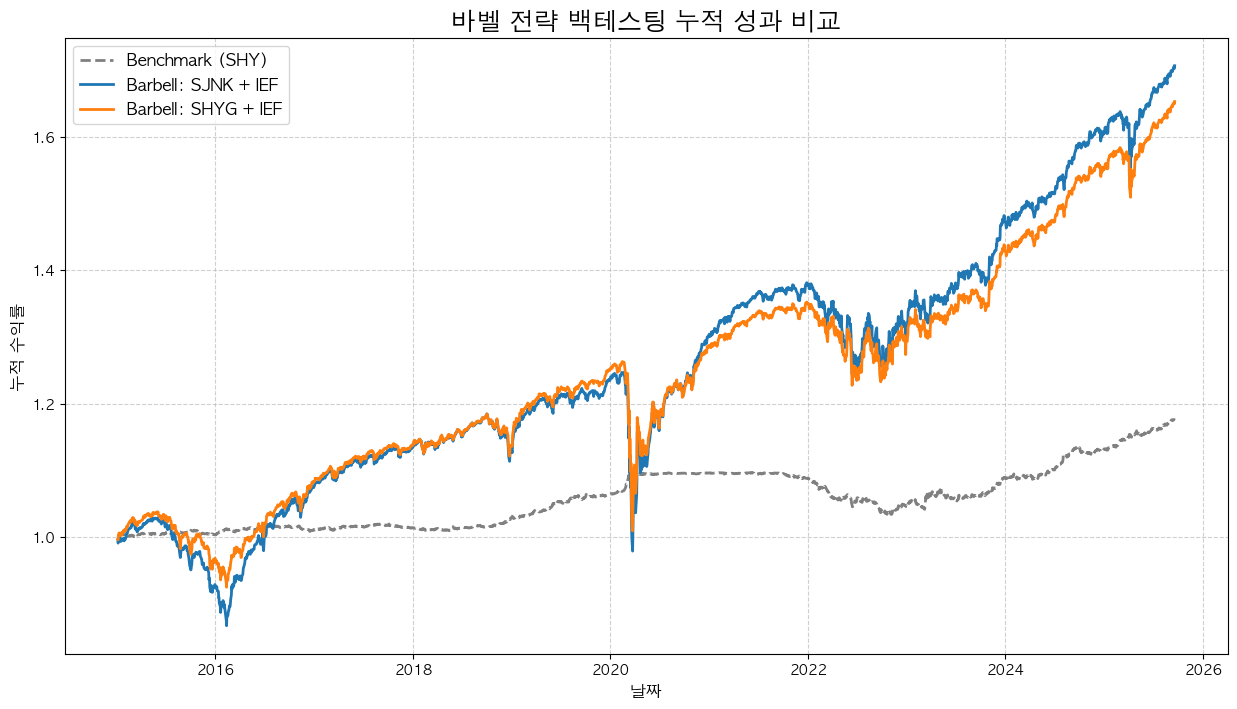

In [4]:
# --- 3. 백테스팅 실행 ---
# 포트폴리오 수익률 계산
returns['Barbell_SJNK'] = returns['SJNK'] * w_sjnk + returns['IEF'] * w_ief_1
returns['Barbell_SHYG'] = returns['SHYG'] * w_shyg + returns['IEF'] * w_ief_2

# 누적 수익률 계산 (초기 투자금 1로 가정)
cumulative_returns = (1 + returns).cumprod()

# --- 누적 성과 시각화 ---
plt.figure(figsize=(15, 8))
plt.plot(cumulative_returns['SHY'], label='Benchmark (SHY)', linewidth=2, color='gray', linestyle='--')
plt.plot(cumulative_returns['Barbell_SJNK'], label='Barbell: SJNK + IEF', linewidth=2)
plt.plot(cumulative_returns['Barbell_SHYG'], label='Barbell: SHYG + IEF', linewidth=2)

plt.title('바벨 전략 백테스팅 누적 성과 비교', fontsize=18)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('누적 수익률', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### ✅ 4단계: OAS 급등 시기 성과 분석
신용 위험이 크게 확대되었던 코로나19 팬데믹 초기(2020년 2월 20일 ~ 2020년 4월 30일) 동안의 성과를 집중적으로 분석하여, 위기 상황에서 바벨 전략이 벤치마크 대비 어떤 모습을 보였는지 확인합니다.

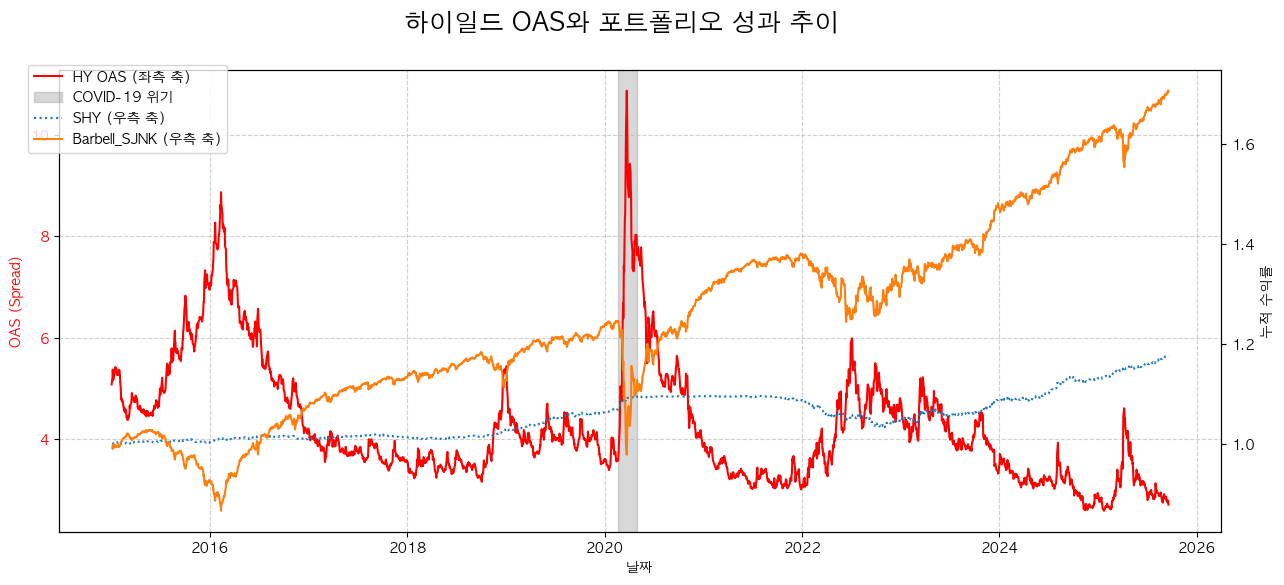


--- OAS 급등 시기 성과 (2020-02-20 ~ 2020-04-30) ---
Benchmark (SHY): 2.46%
Barbell (SJNK+IEF): -9.36%
Barbell (SHYG+IEF): -9.25%


In [5]:
# --- 4. OAS 급등 시기 성과 분석 ---
# OAS 시각화
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df.index, df['OAS'], color='red', label='HY OAS (좌측 축)')
ax1.set_xlabel('날짜')
ax1.set_ylabel('OAS (Spread)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, linestyle='--', alpha=0.6)

# OAS 급등 시기(코로나 팬데믹) 표시
crisis_start = '2020-02-20'
crisis_end = '2020-04-30'
ax1.axvspan(crisis_start, crisis_end, color='gray', alpha=0.3, label='COVID-19 위기')

# 누적 수익률을 우측 축에 표시
ax2 = ax1.twinx()
ax2.plot(cumulative_returns.index, cumulative_returns['SHY'], label='SHY (우측 축)', linestyle=':')
ax2.plot(cumulative_returns.index, cumulative_returns['Barbell_SJNK'], label='Barbell_SJNK (우측 축)')
ax2.set_ylabel('누적 수익률')

fig.suptitle('하이일드 OAS와 포트폴리오 성과 추이', fontsize=18)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()


# 해당 기간 수익률 필터링
crisis_returns = returns.loc[crisis_start:crisis_end]
crisis_performance = (1 + crisis_returns).prod() - 1

print(f"\n--- OAS 급등 시기 성과 ({crisis_start} ~ {crisis_end}) ---")
print(f"Benchmark (SHY): {crisis_performance['SHY']:.2%}")
print(f"Barbell (SJNK+IEF): {crisis_performance['Barbell_SJNK']:.2%}")
print(f"Barbell (SHYG+IEF): {crisis_performance['Barbell_SHYG']:.2%}")

### ✅ 5단계: 다양한 평가지표 확인
전체 기간에 대한 각 포트폴리오의 성과를 다양한 지표로 정량적으로 평가하고 비교합니다.

- 연평균 복리수익률 (CAGR): 투자의 연평균 성장률

- 연평균 변동성: 수익률의 변동성(위험)

- 샤프 지수 (Sharpe Ratio): 위험 대비 수익성 (무위험 수익률 0% 가정)

- 최대 낙폭 (MDD): 전고점 대비 가장 큰 하락률

- 칼마 지수 (Calmar Ratio): MDD 대비 연평균 수익률

In [6]:
# --- 5. 다양한 평가지표 확인 ---
def calculate_performance_metrics(returns_series):
    """
    주어진 수익률 시리즈에 대해 주요 성과 지표를 계산합니다.
    """
    days = len(returns_series)
    trading_days_per_year = 252

    # 연평균 복리수익률 (CAGR)
    total_return = (1 + returns_series).prod()
    cagr = total_return ** (trading_days_per_year / days) - 1

    # 연평균 변동성
    annualized_vol = returns_series.std() * np.sqrt(trading_days_per_year)

    # 샤프 지수
    sharpe_ratio = cagr / annualized_vol

    # 최대 낙폭 (MDD)
    cumulative = (1 + returns_series).cumprod()
    peak = cumulative.expanding(min_periods=1).max()
    drawdown = (cumulative - peak) / peak
    mdd = drawdown.min()

    # 칼마 지수
    calmar_ratio = cagr / abs(mdd)

    return {
        'CAGR (%)': cagr * 100,
        'Volatility (%)': annualized_vol * 100,
        'Sharpe Ratio': sharpe_ratio,
        'MDD (%)': mdd * 100,
        'Calmar Ratio': calmar_ratio
    }

# 각 포트폴리오에 대해 지표 계산
portfolios = ['SHY', 'Barbell_SJNK', 'Barbell_SHYG']
metrics_data = {port: calculate_performance_metrics(returns[port]) for port in portfolios}

# 결과를 DataFrame으로 보기 좋게 정리
metrics_df = pd.DataFrame(metrics_data).T.round(2)

print("\n--- 전체 기간 성과 지표 비교 ---")
print(metrics_df)


--- 전체 기간 성과 지표 비교 ---
              CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  Calmar Ratio
SHY               1.52            1.53          1.00    -5.71          0.27
Barbell_SJNK      5.13            6.94          0.74   -21.48          0.24
Barbell_SHYG      4.82            6.65          0.72   -20.10          0.24


## 2) LONG-ONLY / Maximize Sharpe ratio

In [7]:
from scipy.optimize import minimize

# --- 수정된 2단계: Long-Only 최적 비중 계산 (샤프 지수 최대화) ---

def optimize_sharpe_ratio(returns_df):
    """
    주어진 자산들의 수익률 데이터를 바탕으로 샤프 지수를 최대화하는
    Long-Only 포트폴리오 비중을 계산합니다.
    """
    num_assets = returns_df.shape[1]
    
    # 목적 함수: 마이너스 샤프 지수 (최소화 문제로 변환)
    def negative_sharpe_ratio(weights):
        portfolio_return = np.sum(returns_df.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(returns_df.cov() * 252, weights)))
        # 무위험 수익률은 0으로 가정
        sharpe = portfolio_return / portfolio_vol
        return -sharpe

    # 제약 조건: 모든 가중치의 합은 1
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    
    # 제약 조건: 각 가중치는 0과 1 사이 (Long-Only)
    bounds = tuple((0, 1) for _ in range(num_assets))
    
    # 초기 추정 가중치 (균등 배분)
    initial_weights = np.array(num_assets * [1. / num_assets])
    
    # 최적화 실행
    result = minimize(negative_sharpe_ratio, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    
    return result.x

# --- 최적화 실행 ---
# 포트폴리오 1: SJNK + IEF
optimal_weights_sjnk = optimize_sharpe_ratio(returns[['SJNK', 'IEF']])

# 포트폴리오 2: SHYG + IEF
optimal_weights_shyg = optimize_sharpe_ratio(returns[['SHYG', 'IEF']])


# --- 최적화 결과 및 새로운 포트폴리오 듀레이션 확인 ---
new_w_sjnk, new_w_ief_1 = optimal_weights_sjnk
new_w_shyg, new_w_ief_2 = optimal_weights_shyg

# 최적화된 비중에 따른 포트폴리오의 실제 듀레이션 계산
optimized_duration_1 = new_w_sjnk * DURATIONS['SJNK'] + new_w_ief_1 * DURATIONS['IEF']
optimized_duration_2 = new_w_shyg * DURATIONS['SHYG'] + new_w_ief_2 * DURATIONS['IEF']

print("--- Long-Only 최적화 결과 (샤프 지수 최대화) ---")
print(f"[포트폴리오 1: SJNK + IEF]")
print(f"  - SJNK 최적 비중: {new_w_sjnk:.2%}")
print(f"  - IEF 최적 비중: {new_w_ief_1:.2%}")
print(f"  - 결과 포트폴리오 듀레이션: {optimized_duration_1:.2f}\n")

print(f"[포트폴리오 2: SHYG + IEF]")
print(f"  - SHYG 최적 비중: {new_w_shyg:.2%}")
print(f"  - IEF 최적 비중: {new_w_ief_2:.2%}")
print(f"  - 결과 포트폴리오 듀레이션: {optimized_duration_2:.2f}")

--- Long-Only 최적화 결과 (샤프 지수 최대화) ---
[포트폴리오 1: SJNK + IEF]
  - SJNK 최적 비중: 82.12%
  - IEF 최적 비중: 17.88%
  - 결과 포트폴리오 듀레이션: 3.25

[포트폴리오 2: SHYG + IEF]
  - SHYG 최적 비중: 81.62%
  - IEF 최적 비중: 18.38%
  - 결과 포트폴리오 듀레이션: 3.11


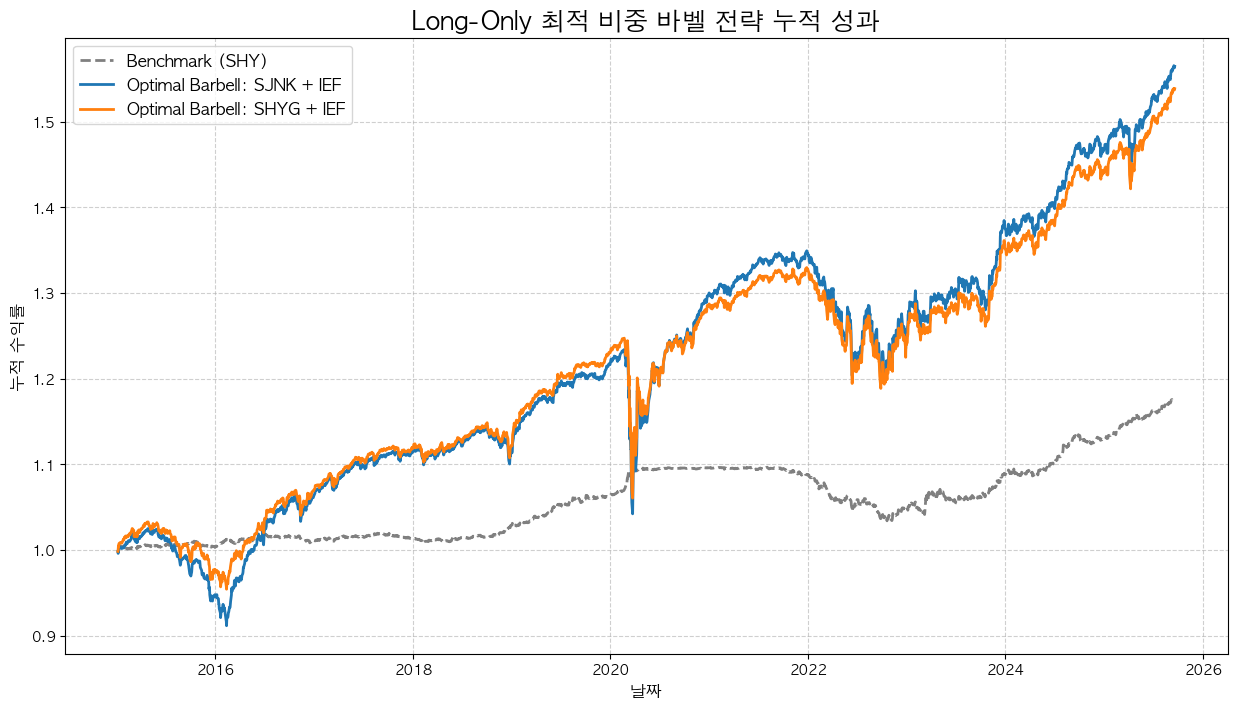


--- OAS 급등 시기 성과 (2020-02-20 ~ 2020-04-30) (최적 비중) ---
Benchmark (SHY): 2.46%
Barbell (SJNK+IEF): -5.37%
Barbell (SHYG+IEF): -5.70%

--- 전체 기간 성과 지표 비교 (최적 비중) ---
                  CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  \
SHY                   1.52            1.53          1.00    -5.71   
Barbell_SJNK_Opt      4.28            5.51          0.78   -15.54   
Barbell_SHYG_Opt      4.12            5.45          0.75   -14.97   

                  Calmar Ratio  
SHY                       0.27  
Barbell_SJNK_Opt          0.28  
Barbell_SHYG_Opt          0.27  


In [8]:
# --- 3. 백테스팅 실행 (최적 비중 사용) ---
returns['Barbell_SJNK_Opt'] = returns['SJNK'] * new_w_sjnk + returns['IEF'] * new_w_ief_1
returns['Barbell_SHYG_Opt'] = returns['SHYG'] * new_w_shyg + returns['IEF'] * new_w_ief_2

cumulative_returns_opt = (1 + returns[['SHY', 'Barbell_SJNK_Opt', 'Barbell_SHYG_Opt']]).cumprod()

# --- 누적 성과 시각화 (최적 비중) ---
plt.figure(figsize=(15, 8))
plt.plot(cumulative_returns_opt['SHY'], label='Benchmark (SHY)', linewidth=2, color='gray', linestyle='--')
plt.plot(cumulative_returns_opt['Barbell_SJNK_Opt'], label='Optimal Barbell: SJNK + IEF', linewidth=2)
plt.plot(cumulative_returns_opt['Barbell_SHYG_Opt'], label='Optimal Barbell: SHYG + IEF', linewidth=2)
plt.title('Long-Only 최적 비중 바벨 전략 누적 성과', fontsize=18)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('누적 수익률', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 4. OAS 급등 시기 성과 분석 (최적 비중) ---
crisis_returns_opt = returns.loc[crisis_start:crisis_end]
crisis_performance_opt = (1 + crisis_returns_opt).prod() - 1

print(f"\n--- OAS 급등 시기 성과 ({crisis_start} ~ {crisis_end}) (최적 비중) ---")
print(f"Benchmark (SHY): {crisis_performance_opt['SHY']:.2%}")
print(f"Barbell (SJNK+IEF): {crisis_performance_opt['Barbell_SJNK_Opt']:.2%}")
print(f"Barbell (SHYG+IEF): {crisis_performance_opt['Barbell_SHYG_Opt']:.2%}")


# --- 5. 다양한 평가지표 확인 (최적 비중) ---
portfolios_opt = ['SHY', 'Barbell_SJNK_Opt', 'Barbell_SHYG_Opt']
metrics_data_opt = {port: calculate_performance_metrics(returns[port]) for port in portfolios_opt}
metrics_df_opt = pd.DataFrame(metrics_data_opt).T.round(2)

print("\n--- 전체 기간 성과 지표 비교 (최적 비중) ---")
print(metrics_df_opt)

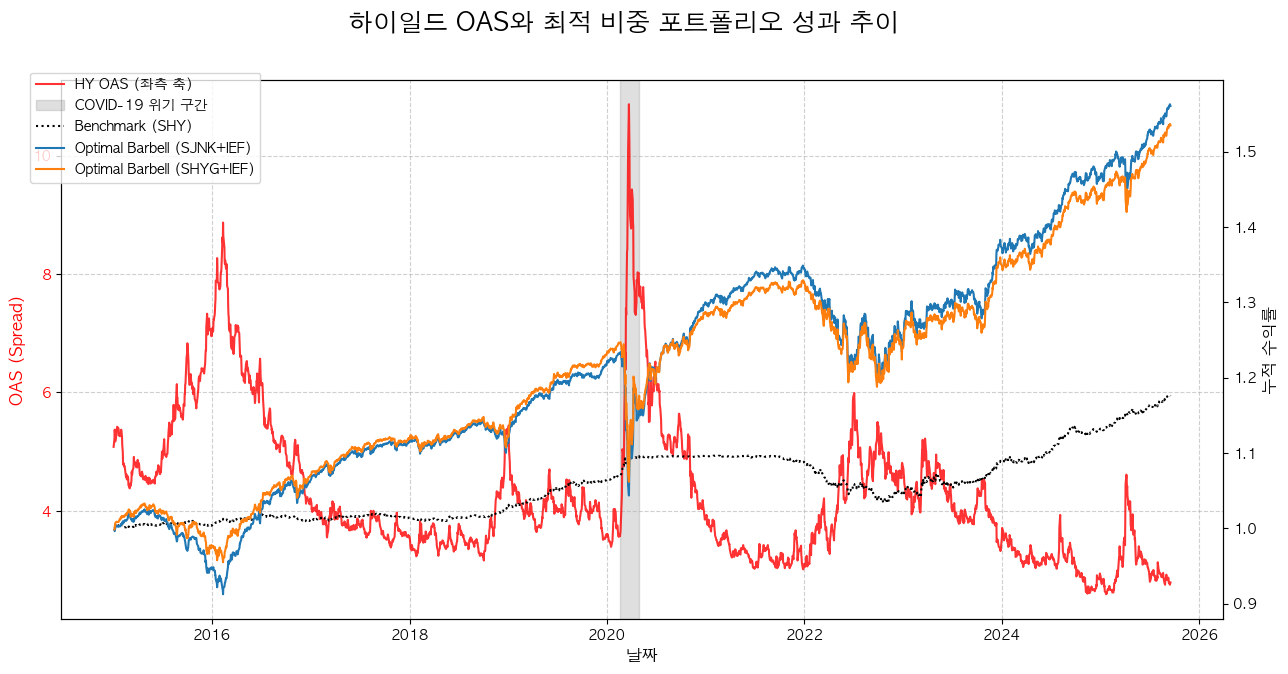

In [11]:
# --- 수정된 4단계: OAS와 최적 포트폴리오 성과 비교 ---

# 시각화
fig, ax1 = plt.subplots(figsize=(15, 7))

# 좌측 축: OAS 데이터
ax1.plot(df.index, df['OAS'], color='red', label='HY OAS (좌측 축)', alpha=0.8)
ax1.set_xlabel('날짜', fontsize=12)
ax1.set_ylabel('OAS (Spread)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, linestyle='--', alpha=0.6)

# OAS 급등 시기(코로나 팬데믹) 음영 표시
crisis_start = '2020-02-20'
crisis_end = '2020-04-30'
ax1.axvspan(crisis_start, crisis_end, color='gray', alpha=0.25, label='COVID-19 위기 구간')

# 우측 축: 포트폴리오 누적 수익률
ax2 = ax1.twinx()
ax2.plot(cumulative_returns_opt.index, cumulative_returns_opt['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
ax2.plot(cumulative_returns_opt.index, cumulative_returns_opt['Barbell_SJNK_Opt'], label='Optimal Barbell (SJNK+IEF)')
ax2.plot(cumulative_returns_opt.index, cumulative_returns_opt['Barbell_SHYG_Opt'], label='Optimal Barbell (SHYG+IEF)')
ax2.set_ylabel('누적 수익률', fontsize=12)

# 차트 제목 및 범례
fig.suptitle('하이일드 OAS와 최적 비중 포트폴리오 성과 추이', fontsize=18)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

## 헷지포트폴리오 

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_14918/4163771579.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_hedge = yf.download(tickers_with_hedge, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed

--- SJB와 OAS 변화량 간의 상관관계 ---
상관계수: 0.6324


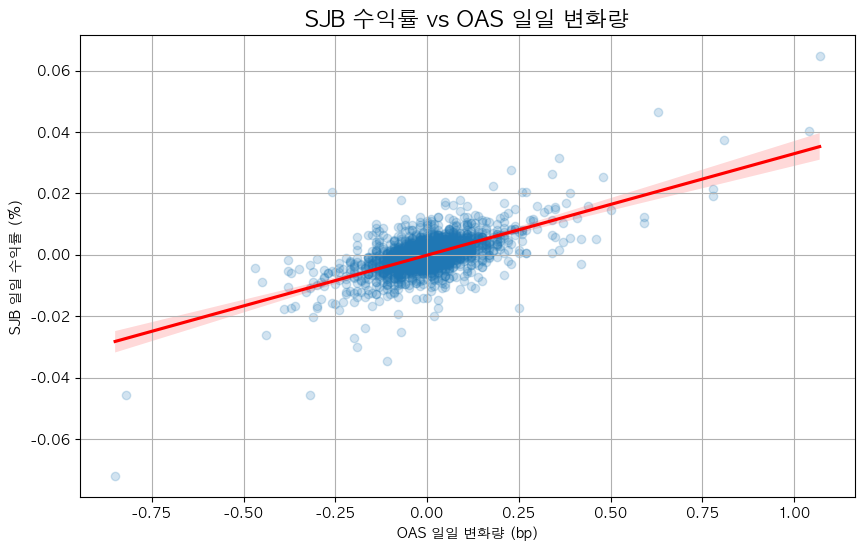

In [9]:
# --- 1. 데이터 준비 (SJB 추가) ---
# 기존 티커에 SJB 추가
tickers_with_hedge = ['SHY', 'IEF', 'SJNK', 'SHYG', 'SJB']
data_hedge = yf.download(tickers_with_hedge, start=start_date, end=end_date)['Close']

# OAS 데이터와 결합
df_hedge = data_hedge.join(oas, how='inner').dropna()

# 일일 수익률 계산
returns_hedge = df_hedge[tickers_with_hedge].pct_change().dropna()

# OAS의 일일 변화량 계산
oas_change = df_hedge['OAS'].diff().dropna()

# --- SJB와 OAS 스프레드 간 상관관계 분석 ---
# 분석을 위해 수익률 데이터와 OAS 변화량 데이터를 합침
analysis_df = pd.concat([returns_hedge['SJB'], oas_change], axis=1).dropna()
analysis_df.columns = ['SJB_Return', 'OAS_Change']

correlation = analysis_df['SJB_Return'].corr(analysis_df['OAS_Change'])

print(f"--- SJB와 OAS 변화량 간의 상관관계 ---")
print(f"상관계수: {correlation:.4f}")

# 시각화
plt.figure(figsize=(10, 6))
sns.regplot(x='OAS_Change', y='SJB_Return', data=analysis_df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('SJB 수익률 vs OAS 일일 변화량', fontsize=16)
plt.xlabel('OAS 일일 변화량 (bp)')
plt.ylabel('SJB 일일 수익률 (%)')
plt.grid(True)
plt.show()

## ✅ 2단계: 동적 헷지 규칙 수립
이제 OAS 수준에 따라 SJB를 편입하는 규칙을 정합니다. 과거 OAS 데이터의 분포를 보고 상위 10% (90th percentile) 수준을 위험 감지 임계값(Threshold)으로 설정하겠습니다.

- 진입 규칙: OAS가 임계값을 상향 돌파하면, 포트폴리오의 **20%**를 SJB로 교체한다.

- 청산 규칙: OAS가 임계값을 다시 하향 돌파하면, SJB를 전량 매도하고 원래의 바벨 포트폴리오 비중으로 복귀한다.

--- 동적 헷지 규칙 ---
OAS 임계값 (상위 10%): 5.97
진입/청산 규칙: OAS가 5.97를 넘으면 포트폴리오의 20%를 SJB로 헷지


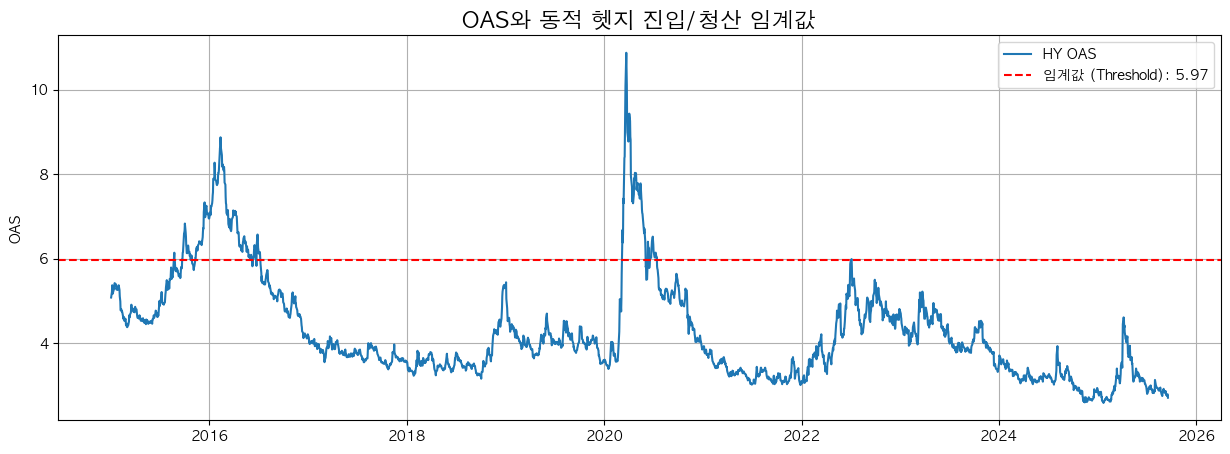

In [10]:
# --- 2. 동적 헷지 규칙 수립 ---

# OAS 임계값 설정 (과거 데이터 기준 상위 10% 지점)
oas_threshold = df_hedge['OAS'].quantile(0.90)

# 헷지 비중 설정
hedge_weight = 0.20 # 위험 시그널 발생 시 SJB에 20% 할당

print(f"--- 동적 헷지 규칙 ---")
print(f"OAS 임계값 (상위 10%): {oas_threshold:.2f}")
print(f"진입/청산 규칙: OAS가 {oas_threshold:.2f}를 넘으면 포트폴리오의 {hedge_weight:.0%}를 SJB로 헷지")

# 시각화: OAS와 임계값
plt.figure(figsize=(15, 5))
plt.plot(df_hedge.index, df_hedge['OAS'], label='HY OAS')
plt.axhline(oas_threshold, color='red', linestyle='--', label=f'임계값 (Threshold): {oas_threshold:.2f}')
plt.title('OAS와 동적 헷지 진입/청산 임계값', fontsize=16)
plt.ylabel('OAS')
plt.legend()
plt.grid(True)
plt.show()

## ✅ 3단계: 동적 백테스팅 실행
수립된 규칙에 따라 일별로 포트폴리오 비중을 조정하며 수익률을 계산하는 동적 백테스팅을 실행합니다.

In [11]:
# --- 3. 동적 백테스팅 실행 (수정된 코드) ---

# 최적 비중 (이전 단계에서 계산)
# new_w_sjnk, new_w_ief_1
# new_w_shyg, new_w_ief_2

# 동적 헷지 포트폴리오 수익률을 저장할 시리즈 초기화
returns_hedge['Hedged_SJNK'] = 0.0
returns_hedge['Hedged_SHYG'] = 0.0

# 날짜를 순회하며 동적 리밸런싱 적용
# ----------------- [수정된 부분 START] -----------------
# 반복문의 기준을 길이가 짧은 returns_hedge로 변경하고,
# 인덱싱 방식을 날짜에 맞게 조정합니다.

for i in range(len(returns_hedge)):
    # 오늘의 포지션을 결정하기 위해, "어제의 OAS 값"을 참조해야 합니다.
    # returns_hedge[i]는 df_hedge[i+1] 시점의 수익률이므로, 어제의 OAS는 df_hedge[i]가 됩니다.
    is_hedge_active = df_hedge['OAS'].iloc[i] > oas_threshold
    
    # SJNK 기반 포트폴리오
    if is_hedge_active:
        # 헷지 발동: 기존 포트폴리오 비중을 (1-헷지비중)만큼 줄이고, SJB 편입
        daily_return = (returns_hedge['SJNK'].iloc[i] * new_w_sjnk * (1 - hedge_weight) +
                        returns_hedge['IEF'].iloc[i] * new_w_ief_1 * (1 - hedge_weight) +
                        returns_hedge['SJB'].iloc[i] * hedge_weight)
        returns_hedge.loc[returns_hedge.index[i], 'Hedged_SJNK'] = daily_return
    else:
        # 평상시: 원래의 최적 비중 유지
        daily_return = (returns_hedge['SJNK'].iloc[i] * new_w_sjnk +
                        returns_hedge['IEF'].iloc[i] * new_w_ief_1)
        returns_hedge.loc[returns_hedge.index[i], 'Hedged_SJNK'] = daily_return

    # SHYG 기반 포트폴리오
    if is_hedge_active:
        daily_return = (returns_hedge['SHYG'].iloc[i] * new_w_shyg * (1 - hedge_weight) +
                        returns_hedge['IEF'].iloc[i] * new_w_ief_2 * (1 - hedge_weight) +
                        returns_hedge['SJB'].iloc[i] * hedge_weight)
        returns_hedge.loc[returns_hedge.index[i], 'Hedged_SHYG'] = daily_return
    else:
        daily_return = (returns_hedge['SHYG'].iloc[i] * new_w_shyg +
                        returns_hedge['IEF'].iloc[i] * new_w_ief_2)
        returns_hedge.loc[returns_hedge.index[i], 'Hedged_SHYG'] = daily_return
# ----------------- [수정된 부분 END] -----------------

print("동적 백테스팅 계산이 정상적으로 완료되었습니다.")

동적 백테스팅 계산이 정상적으로 완료되었습니다.


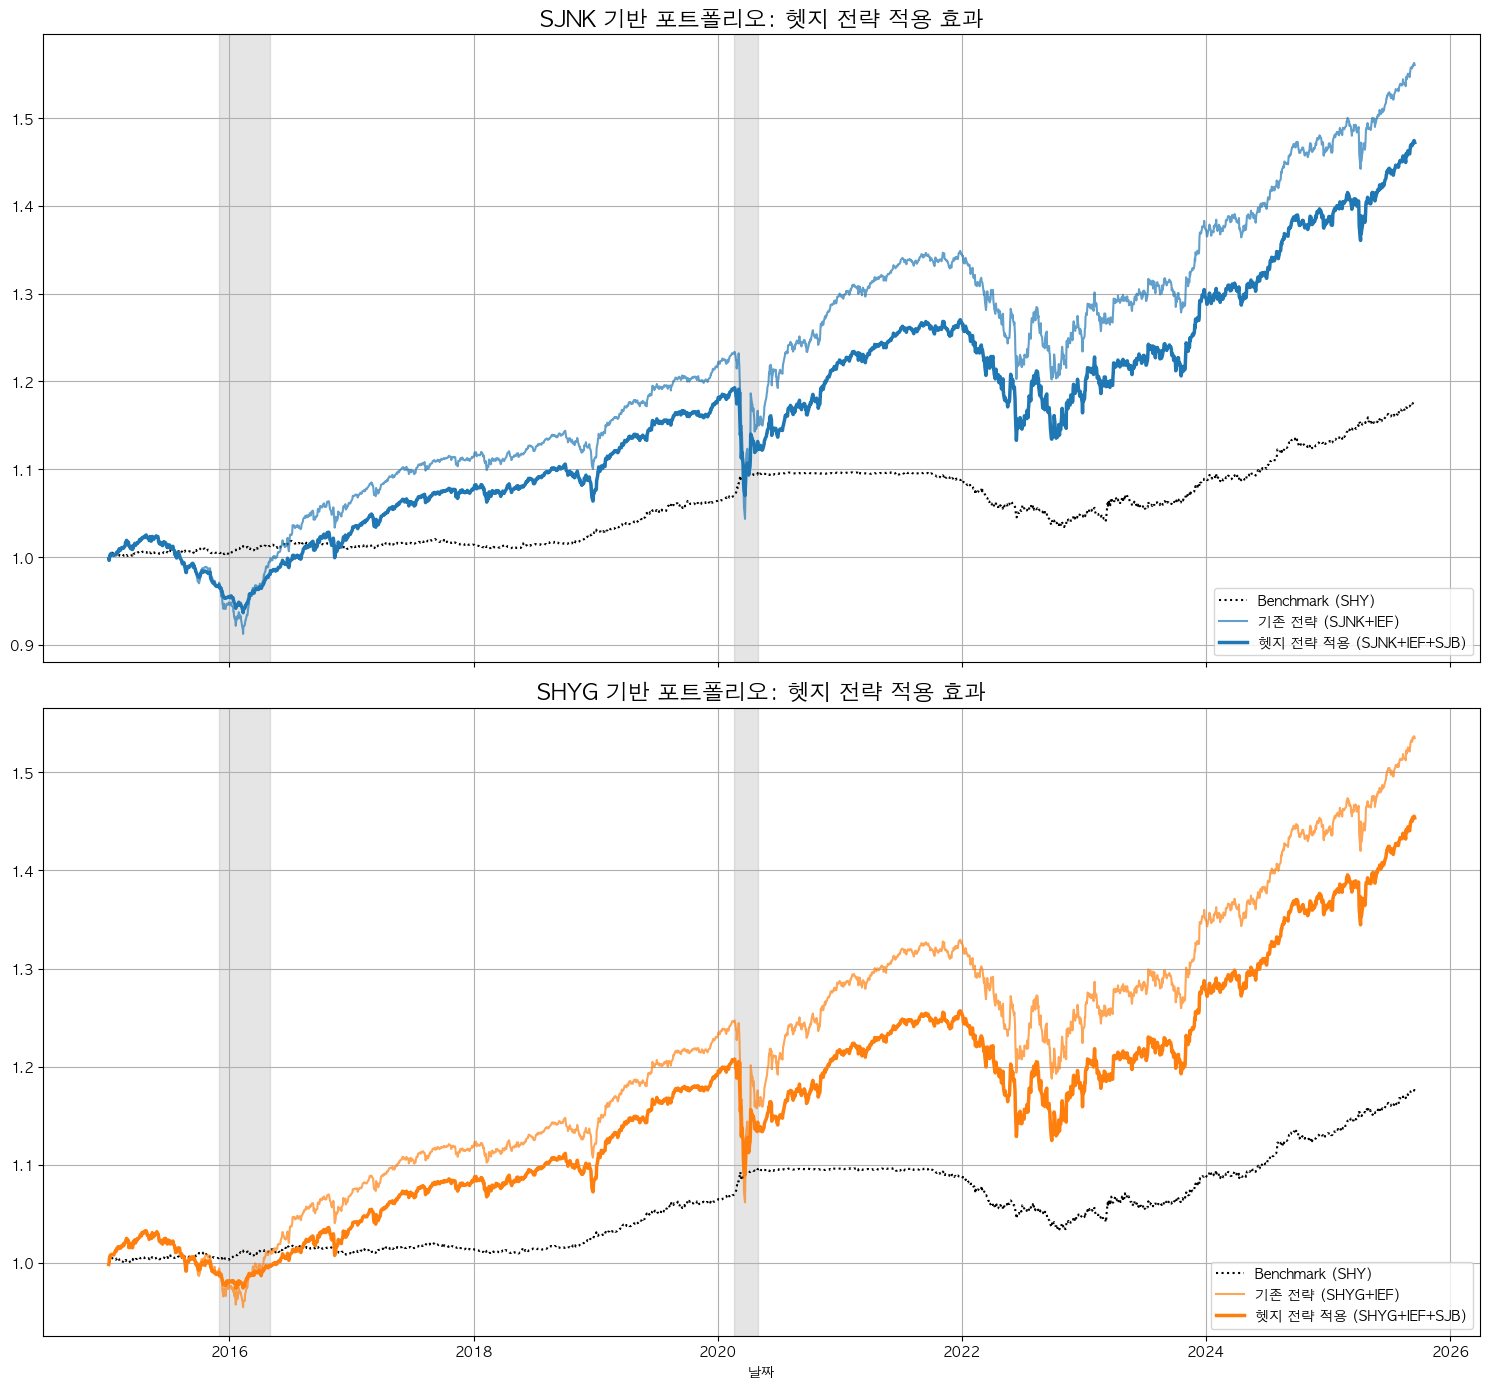

In [18]:
# --- 4.1 누적 성과 비교 ---
# 비교를 위해 기존 최적 포트폴리오 수익률도 복사
returns_hedge['Barbell_SJNK_Opt'] = returns['Barbell_SJNK_Opt']
returns_hedge['Barbell_SHYG_Opt'] = returns['Barbell_SHYG_Opt']

# 누적 수익률 계산
cumulative_returns_final = (1 + returns_hedge[['SHY', 'Barbell_SJNK_Opt', 'Hedged_SJNK', 'Barbell_SHYG_Opt', 'Hedged_SHYG']]).cumprod()

# 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14), sharex=True)

# SJNK 기반 포트폴리오 비교
ax1.plot(cumulative_returns_final['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
ax1.plot(cumulative_returns_final['Barbell_SJNK_Opt'], label='기존 전략 (SJNK+IEF)', color='C0', alpha=0.7)
ax1.plot(cumulative_returns_final['Hedged_SJNK'], label='헷지 전략 적용 (SJNK+IEF+SJB)', color='C0', linewidth=2.5)
ax1.set_title('SJNK 기반 포트폴리오: 헷지 전략 적용 효과', fontsize=16)
ax1.legend()
ax1.grid(True)
ax1.axvspan('2015-12-01', '2016-04-30', color='gray', alpha=0.2) # 2016 위기
ax1.axvspan(crisis_start, crisis_end, color='gray', alpha=0.2) # 2020 위기

# SHYG 기반 포트폴리오 비교
ax2.plot(cumulative_returns_final['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
ax2.plot(cumulative_returns_final['Barbell_SHYG_Opt'], label='기존 전략 (SHYG+IEF)', color='C1', alpha=0.7)
ax2.plot(cumulative_returns_final['Hedged_SHYG'], label='헷지 전략 적용 (SHYG+IEF+SJB)', color='C1', linewidth=2.5)
ax2.set_title('SHYG 기반 포트폴리오: 헷지 전략 적용 효과', fontsize=16)
ax2.legend()
ax2.grid(True)
ax2.axvspan('2015-12-01', '2016-04-30', color='gray', alpha=0.2) # 2016 위기
ax2.axvspan(crisis_start, crisis_end, color='gray', alpha=0.2) # 2020 위기

plt.xlabel('날짜')
plt.tight_layout()
plt.show()

In [20]:
# --- 4.2 성과 지표 비교 ---
portfolios_final = ['SHY', 'Barbell_SJNK_Opt', 'Hedged_SJNK', 'Barbell_SHYG_Opt', 'Hedged_SHYG']
metrics_data_final = {port: calculate_performance_metrics(returns_hedge[port]) for port in portfolios_final}
metrics_df_final = pd.DataFrame(metrics_data_final).T.round(2)

print("\n--- 최종 성과 지표 비교 (헷지 전략 포함) ---")
metrics_df_final


--- 최종 성과 지표 비교 (헷지 전략 포함) ---


,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
SHY,1.53,1.53,1.00,-5.71,0.27
Barbell_SJNK_Opt,4.26,5.49,0.78,-15.43,0.28
Hedged_SJNK,3.69,4.64,0.80,-10.82,0.34
Barbell_SHYG_Opt,4.09,5.43,0.75,-14.86,0.28
Hedged_SHYG,3.56,4.58,0.78,-10.52,0.34


## 룩어헤드 방지 

--- 시차(Lag)가 적용된 동적 헷지 규칙 ---
OAS 임계값 (상위 10%): 5.97
진입/청산 규칙: '어제' 마감 OAS가 5.97를 넘으면 '오늘' 포트폴리오의 20%를 SJB로 헷지


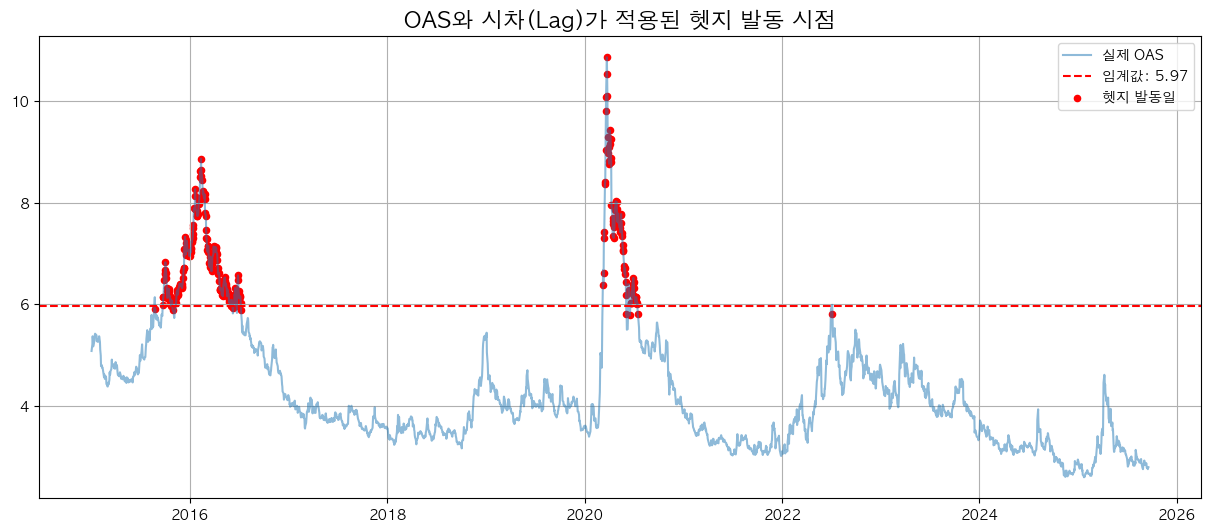

In [21]:
# --- 2. 동적 헷지 규칙 수립 (1-Day Lag 적용) ---

# OAS 임계값은 전체 데이터 분포를 사용하므로 기존과 동일
oas_threshold = df_hedge['OAS'].quantile(0.90)
hedge_weight = 0.20

# [수정] 헷지 신호를 만들 때 하루 전(T-1) OAS 값을 사용
df_hedge['OAS_Lagged'] = df_hedge['OAS'].shift(1)
df_hedge['Hedge_Signal'] = df_hedge['OAS_Lagged'] > oas_threshold

print(f"--- 시차(Lag)가 적용된 동적 헷지 규칙 ---")
print(f"OAS 임계값 (상위 10%): {oas_threshold:.2f}")
print(f"진입/청산 규칙: '어제' 마감 OAS가 {oas_threshold:.2f}를 넘으면 '오늘' 포트폴리오의 {hedge_weight:.0%}를 SJB로 헷지")

# 시각화: 실제 OAS와 헷지 발동 시점 비교
plt.figure(figsize=(15, 6))
plt.plot(df_hedge.index, df_hedge['OAS'], label='실제 OAS', alpha=0.5)
plt.axhline(oas_threshold, color='red', linestyle='--', label=f'임계값: {oas_threshold:.2f}')

# 헷지가 실제로 발동되는 날짜(신호 다음날)를 표시
hedge_active_dates = df_hedge[df_hedge['Hedge_Signal']].index
plt.scatter(hedge_active_dates, df_hedge.loc[hedge_active_dates, 'OAS'], 
            color='red', marker='o', s=20, label='헷지 발동일')

plt.title('OAS와 시차(Lag)가 적용된 헷지 발동 시점', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# --- 3. 동적 백테스팅 실행 (1-Day Lag 적용) ---

# 이전 단계에서 에러가 발생했던 복잡한 loop 대신,
# 미리 만들어 둔 'Hedge_Signal'을 사용하여 계산을 다시 진행합니다.
# 데이터프레임 전체에 대해 벡터화 연산을 수행하여 더 빠르고 간결합니다.

# 헷지 비중이 적용된 수익률과 기본 수익률을 계산
# SJNK 기반 포트폴리오
base_return_sjnk = returns_hedge['SJNK'] * new_w_sjnk + returns_hedge['IEF'] * new_w_ief_1
hedge_return_sjnk = (returns_hedge['SJNK'] * new_w_sjnk * (1 - hedge_weight) +
                     returns_hedge['IEF'] * new_w_ief_1 * (1 - hedge_weight) +
                     returns_hedge['SJB'] * hedge_weight)

# SHYG 기반 포트폴리오
base_return_shyg = returns_hedge['SHYG'] * new_w_shyg + returns_hedge['IEF'] * new_w_ief_2
hedge_return_shyg = (returns_hedge['SHYG'] * new_w_shyg * (1 - hedge_weight) +
                     returns_hedge['IEF'] * new_w_ief_2 * (1 - hedge_weight) +
                     returns_hedge['SJB'] * hedge_weight)


# Hedge_Signal에 따라 두 수익률 중 하나를 선택
# np.where(조건, 참일 때 값, 거짓일 때 값)
# 주의: returns_hedge와 df_hedge의 인덱스를 맞춰주기 위해 .reindex() 사용
hedge_signal_aligned = df_hedge['Hedge_Signal'].reindex(returns_hedge.index).fillna(False)

returns_hedge['Hedged_SJNK_Lagged'] = np.where(hedge_signal_aligned, hedge_return_sjnk, base_return_sjnk)
returns_hedge['Hedged_SHYG_Lagged'] = np.where(hedge_signal_aligned, hedge_return_shyg, base_return_shyg)


print("시차(Lag)를 적용한 동적 백테스팅 계산이 완료되었습니다.")

시차(Lag)를 적용한 동적 백테스팅 계산이 완료되었습니다.


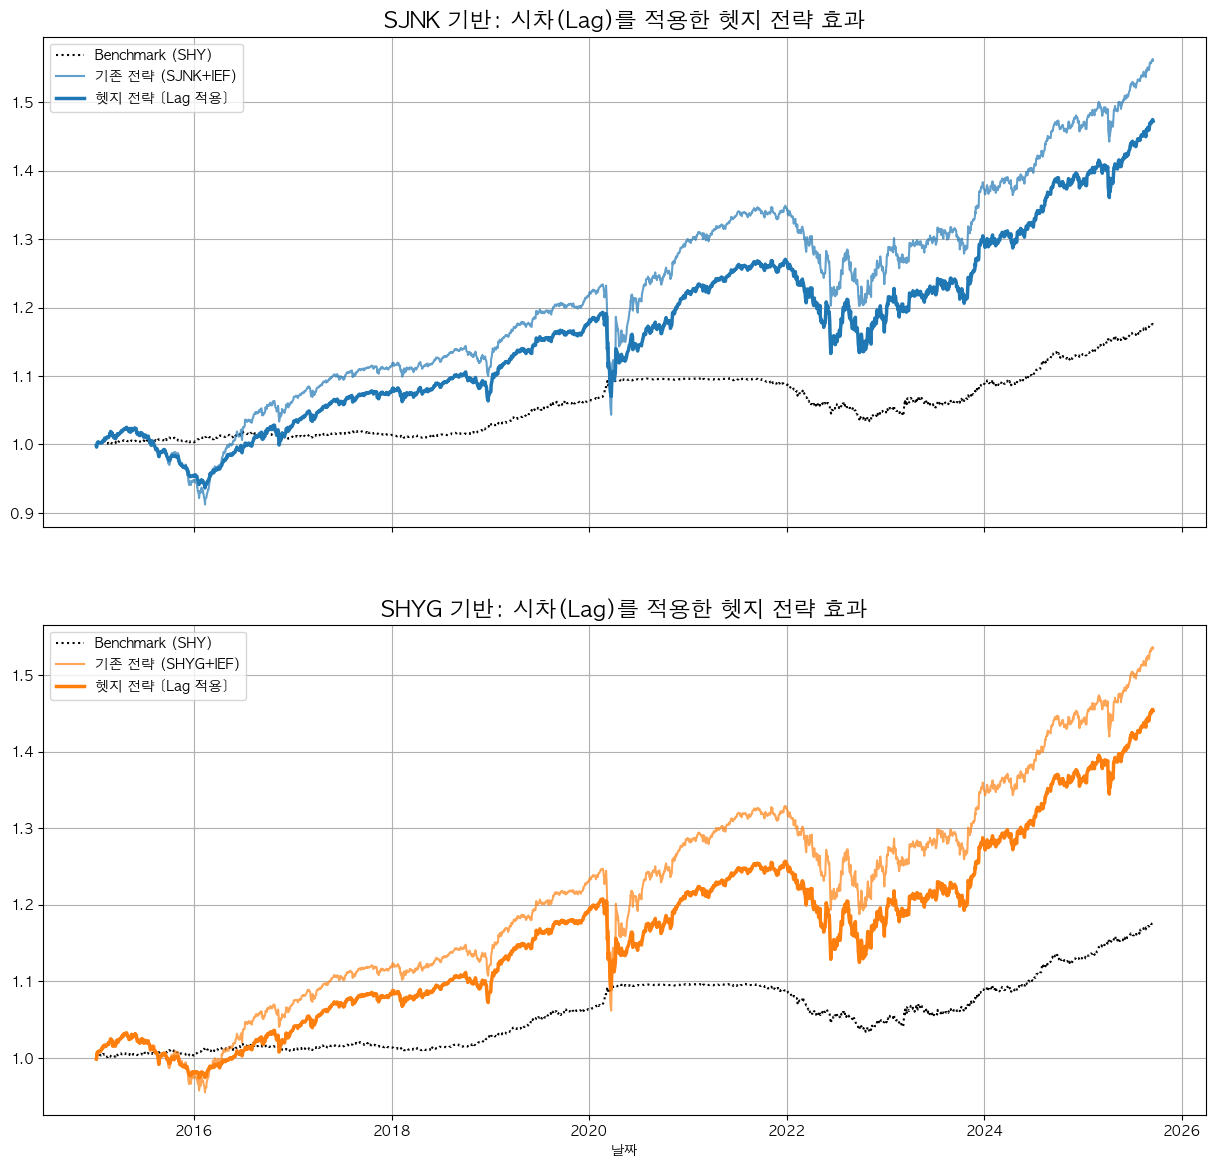


--- 최종 성과 지표 비교 (시차 적용된 헷지 전략 포함) ---
                    CAGR (%)  Volatility (%)  Sharpe Ratio  MDD (%)  \
SHY                     1.53            1.53          1.00    -5.71   
Barbell_SJNK_Opt        4.26            5.49          0.78   -15.43   
Hedged_SJNK_Lagged      3.69            4.64          0.80   -10.82   
Barbell_SHYG_Opt        4.09            5.43          0.75   -14.86   
Hedged_SHYG_Lagged      3.56            4.58          0.78   -10.52   

                    Calmar Ratio  
SHY                         0.27  
Barbell_SJNK_Opt            0.28  
Hedged_SJNK_Lagged          0.34  
Barbell_SHYG_Opt            0.28  
Hedged_SHYG_Lagged          0.34  


In [ ]:
# --- 4. 최종 성과 비교 및 평가 (Lag 적용) ---

# 누적 수익률 계산
cumulative_returns_lagged = (1 + returns_hedge[['SHY', 'Barbell_SJNK_Opt', 'Hedged_SJNK_Lagged', 'Barbell_SHYG_Opt', 'Hedged_SHYG_Lagged']]).cumprod()

# 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14), sharex=True)
ax1.plot(cumulative_returns_lagged['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
ax1.plot(cumulative_returns_lagged['Barbell_SJNK_Opt'], label='기존 전략 (SJNK+IEF)', color='C0', alpha=0.7)
ax1.plot(cumulative_returns_lagged['Hedged_SJNK_Lagged'], label='헷지 전략 [Lag 적용]', color='C0', linewidth=2.5)
ax1.set_title('SJNK 기반: 시차(Lag)를 적용한 헷지 전략 효과', fontsize=16)
ax1.legend()
ax1.grid(True)

ax2.plot(cumulative_returns_lagged['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
ax2.plot(cumulative_returns_lagged['Barbell_SHYG_Opt'], label='기존 전략 (SHYG+IEF)', color='C1', alpha=0.7)
ax2.plot(cumulative_returns_lagged['Hedged_SHYG_Lagged'], label='헷지 전략 [Lag 적용]', color='C1', linewidth=2.5)
ax2.set_title('SHYG 기반: 시차(Lag)를 적용한 헷지 전략 효과', fontsize=16)
ax2.legend()
ax2.grid(True)
plt.xlabel('날짜')
plt.show()

# 성과 지표 비교
portfolios_lagged = ['SHY', 'Barbell_SJNK_Opt', 'Hedged_SJNK_Lagged', 'Barbell_SHYG_Opt', 'Hedged_SHYG_Lagged']
metrics_data_lagged = {port: calculate_performance_metrics(returns_hedge[port].dropna()) for port in portfolios_lagged}
metrics_df_lagged = pd.DataFrame(metrics_data_lagged).T.round(2)

print("\n--- 최종 성과 지표 비교 (시차 적용된 헷지 전략 포함) ---")
metrics_df_lagged

In [24]:
metrics_df_lagged

,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
SHY,1.53,1.53,1.00,-5.71,0.27
Barbell_SJNK_Opt,4.26,5.49,0.78,-15.43,0.28
Hedged_SJNK_Lagged,3.69,4.64,0.80,-10.82,0.34
Barbell_SHYG_Opt,4.09,5.43,0.75,-14.86,0.28
Hedged_SHYG_Lagged,3.56,4.58,0.78,-10.52,0.34


## 헷지비율 최적화 백테스팅

In [25]:
# --- 1. 헷지 비율 최적화 백테스팅 ---

# 테스트할 헷지 비율 목록
hedge_ratios_to_test = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# 결과를 저장할 리스트 초기화
all_results = []

# SJNK 기반 포트폴리오를 기준으로 최적화 진행
# (SHYG도 결과는 거의 유사하므로 대표로 SJNK를 사용)
base_return_sjnk = returns_hedge['SJNK'] * new_w_sjnk + returns_hedge['IEF'] * new_w_ief_1
hedge_signal_aligned = df_hedge['Hedge_Signal'].reindex(returns_hedge.index).fillna(False)

print("헷지 비율 최적화 백테스팅을 시작합니다...")

# 각 헷지 비율에 대해 반복 실행
for ratio in hedge_ratios_to_test:
    # 해당 헷지 비율이 적용된 수익률 계산
    hedge_return_sjnk = (returns_hedge['SJNK'] * new_w_sjnk * (1 - ratio) +
                         returns_hedge['IEF'] * new_w_ief_1 * (1 - ratio) +
                         returns_hedge['SJB'] * ratio)
    
    # 동적 포트폴리오 수익률 계산
    dynamic_returns = np.where(hedge_signal_aligned, hedge_return_sjnk, base_return_sjnk)
    
    # Series로 변환해야 성과측정 함수 사용 가능
    dynamic_returns_series = pd.Series(dynamic_returns, index=returns_hedge.index)
    
    # 성과 지표 계산
    metrics = calculate_performance_metrics(dynamic_returns_series)
    metrics['Hedge Ratio'] = f"{ratio:.0%}" # 헷지 비율 추가
    
    # 결과 저장
    all_results.append(metrics)

# 결과를 DataFrame으로 변환
results_df = pd.DataFrame(all_results).set_index('Hedge Ratio')

print("최적화 백테스팅 완료.")

헷지 비율 최적화 백테스팅을 시작합니다...
최적화 백테스팅 완료.


In [27]:
# --- 2.1 결과 테이블 ---
print("\n--- 헷지 비율별 성과 지표 비교 ---")
results_df.round(2)


--- 헷지 비율별 성과 지표 비교 ---


,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
Hedge Ratio,,,,,
0%,4.26,5.49,0.78,-15.43,0.28
5%,4.12,5.23,0.79,-14.17,0.29
10%,3.98,5.00,0.80,-12.89,0.31
15%,3.83,4.80,0.80,-11.60,0.33
20%,3.69,4.64,0.80,-10.82,0.34
25%,3.54,4.51,0.78,-10.82,0.33
30%,3.39,4.43,0.77,-10.82,0.31


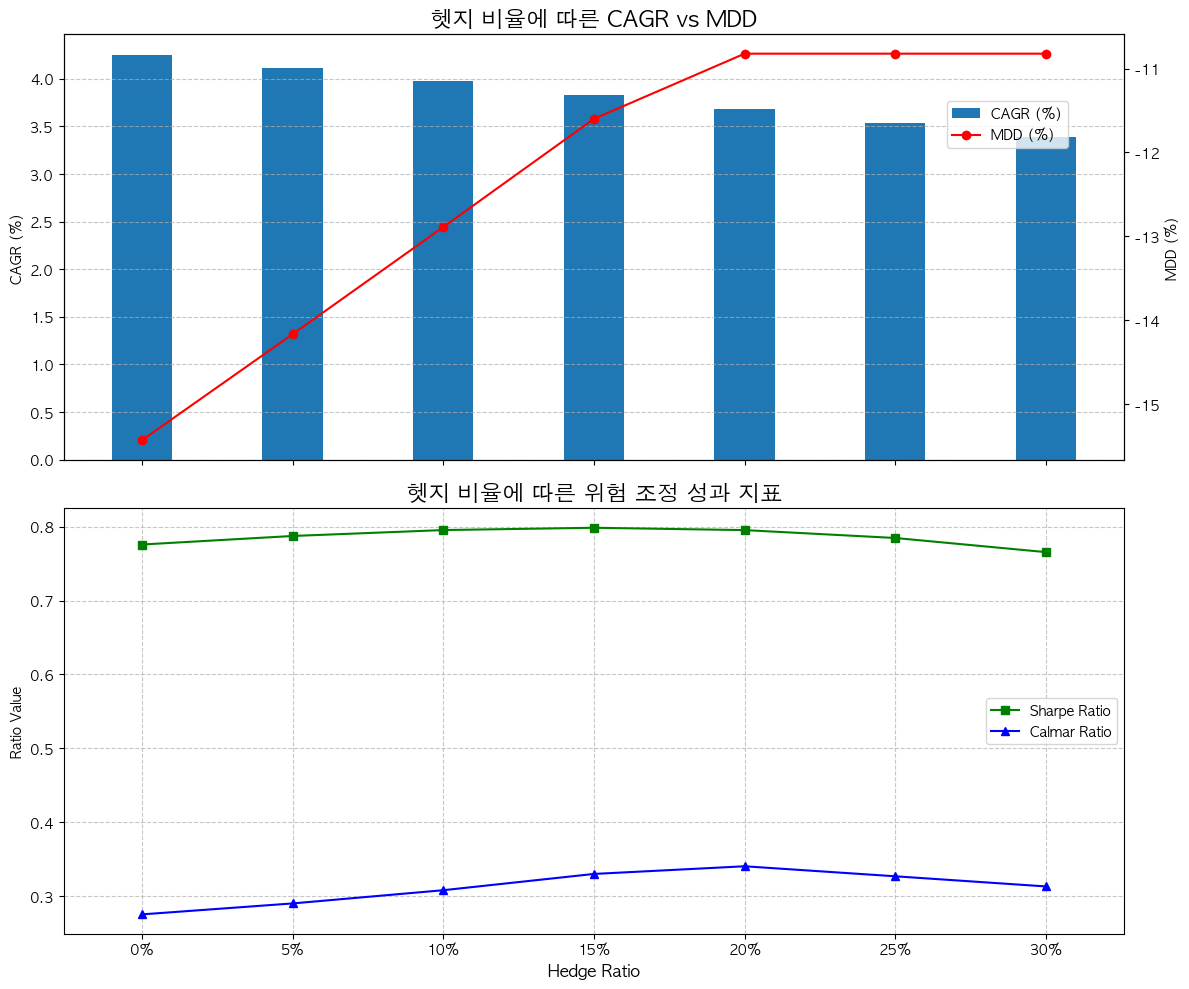

In [28]:
# --- 2.2 결과 시각화 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# CAGR과 MDD의 Trade-off 관계 시각화
ax1.bar(results_df.index, results_df['CAGR (%)'], label='CAGR (%)', width=0.4)
ax1.set_ylabel('CAGR (%)')
ax1.set_title('헷지 비율에 따른 CAGR vs MDD', fontsize=16)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax1_twin = ax1.twinx()
ax1_twin.plot(results_df.index, results_df['MDD (%)'], 'r-o', label='MDD (%)')
ax1_twin.set_ylabel('MDD (%)')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

# Sharpe Ratio와 Calmar Ratio 시각화 (최적 지점 찾기)
ax2.plot(results_df.index, results_df['Sharpe Ratio'], 'g-s', label='Sharpe Ratio')
ax2.plot(results_df.index, results_df['Calmar Ratio'], 'b-^', label='Calmar Ratio')
ax2.set_title('헷지 비율에 따른 위험 조정 성과 지표', fontsize=16)
ax2.set_xlabel('Hedge Ratio', fontsize=12)
ax2.set_ylabel('Ratio Value')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

### 헷지 신호 이평선 활용 - SJNK

In [29]:
# --- 1. 신호 정교화 백테스팅 ---

# 헷지 비율은 20%로 고정
hedge_ratio = 0.20

# --- A. 동적 임계값 (Moving Average) 신호 생성 ---
# 50일 이동평균 계산
df_hedge['OAS_SMA50'] = df_hedge['OAS'].rolling(window=50).mean()

# 신호 생성 (시차 1일 적용)
df_hedge['Signal_A_Dynamic'] = (df_hedge['OAS'] > df_hedge['OAS_SMA50']).shift(1)


# --- B. 모멘텀 결합 신호 생성 ---
# 기존 정적 임계값
oas_threshold = df_hedge['OAS'].quantile(0.90)

# 5일 변화율(모멘텀) 계산 및 임계값 설정
df_hedge['OAS_ROC5'] = df_hedge['OAS'].diff(5)
roc_threshold = df_hedge['OAS_ROC5'].quantile(0.90)

# 신호 생성 (시차 1일 적용)
signal_condition = (df_hedge['OAS'] > oas_threshold) & (df_hedge['OAS_ROC5'] > roc_threshold)
df_hedge['Signal_B_Combined'] = signal_condition.shift(1)


# --- 백테스팅 실행 ---
# SJNK 기반 포트폴리오 기준
base_return_sjnk = returns_hedge['SJNK'] * new_w_sjnk + returns_hedge['IEF'] * new_w_ief_1
hedge_return_sjnk = (returns_hedge['SJNK'] * new_w_sjnk * (1 - hedge_ratio) +
                     returns_hedge['IEF'] * new_w_ief_1 * (1 - hedge_ratio) +
                     returns_hedge['SJB'] * hedge_ratio)

# 각 신호에 맞게 인덱스 정렬
signal_a_aligned = df_hedge['Signal_A_Dynamic'].reindex(returns_hedge.index).fillna(False)
signal_b_aligned = df_hedge['Signal_B_Combined'].reindex(returns_hedge.index).fillna(False)

# 포트폴리오 수익률 계산
returns_hedge['Hedged_A_Dynamic'] = np.where(signal_a_aligned, hedge_return_sjnk, base_return_sjnk)
returns_hedge['Hedged_B_Combined'] = np.where(signal_b_aligned, hedge_return_sjnk, base_return_sjnk)

print("두 가지 신호 정교화 전략에 대한 백테스팅을 완료했습니다.")

두 가지 신호 정교화 전략에 대한 백테스팅을 완료했습니다.


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_4767/1202007986.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  signal_a_aligned = df_hedge['Signal_A_Dynamic'].reindex(returns_hedge.index).fillna(False)
/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_4767/1202007986.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  signal_b_aligned = df_hedge['Signal_B_Combined'].reindex(returns_hedge.index).fillna(False)


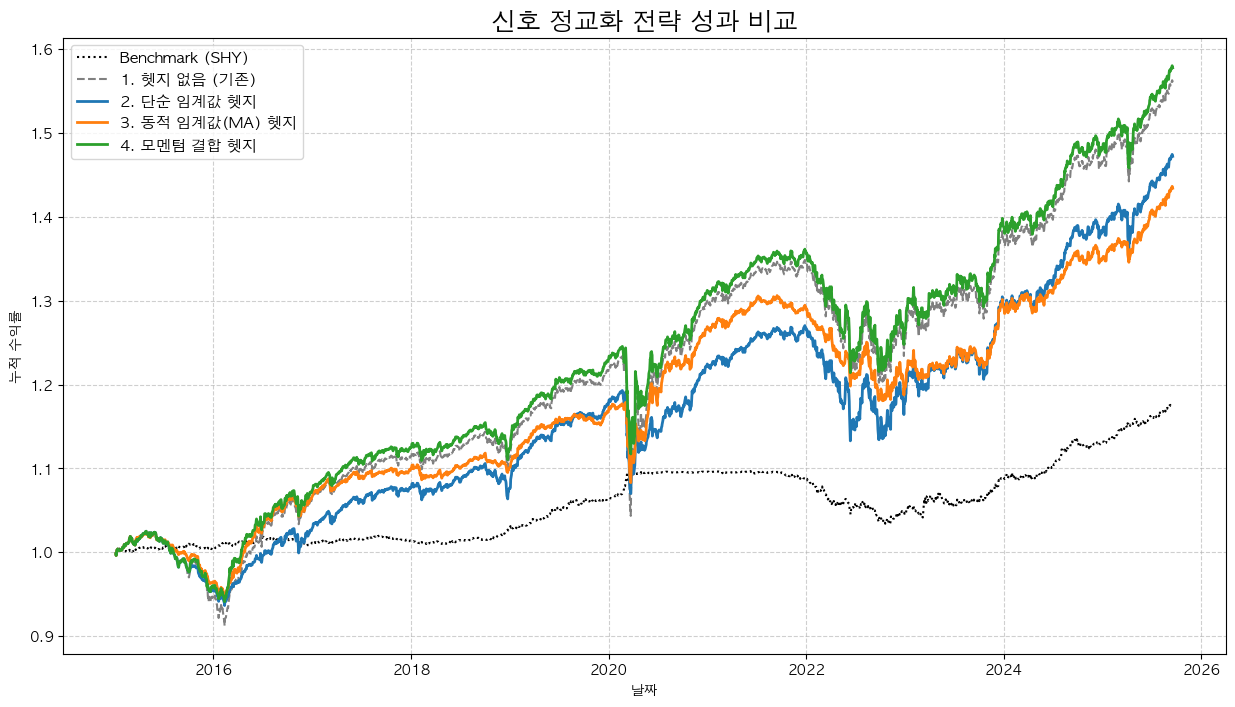

In [30]:
# --- 2.1 누적 수익률 그래프 비교 ---

# 비교 대상 포트폴리오: 헷지 없음, 단순 임계값, 동적 임계값, 모멘텀 결합
comparison_list = ['SHY', 'Barbell_SJNK_Opt', 'Hedged_SJNK_Lagged', 'Hedged_A_Dynamic', 'Hedged_B_Combined']
cumulative_returns_final = (1 + returns_hedge[comparison_list].dropna()).cumprod()

# 시각화
plt.figure(figsize=(15, 8))
plt.plot(cumulative_returns_final['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
plt.plot(cumulative_returns_final['Barbell_SJNK_Opt'], label='1. 헷지 없음 (기존)', linestyle='--', color='gray')
plt.plot(cumulative_returns_final['Hedged_SJNK_Lagged'], label='2. 단순 임계값 헷지', linewidth=2.0)
plt.plot(cumulative_returns_final['Hedged_A_Dynamic'], label='3. 동적 임계값(MA) 헷지', linewidth=2.0)
plt.plot(cumulative_returns_final['Hedged_B_Combined'], label='4. 모멘텀 결합 헷지', linewidth=2.0)

plt.title('신호 정교화 전략 성과 비교', fontsize=18)
plt.xlabel('날짜')
plt.ylabel('누적 수익률')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [32]:
# --- 2.2 성과 지표 테이블 비교 ---

portfolios_final_comparison = ['SHY', 'Barbell_SJNK_Opt', 'Hedged_SJNK_Lagged', 'Hedged_A_Dynamic', 'Hedged_B_Combined']
metrics_data_final = {port: calculate_performance_metrics(returns_hedge[port].dropna()) for port in portfolios_final_comparison}
metrics_df_final = pd.DataFrame(metrics_data_final).T.round(2)
metrics_df_final.index = ['벤치마크 (SHY)', '1. 헷지 없음', '2. 단순 임계값', '3. 동적 임계값(MA)', '4. 모멘텀 결합']

print("\n--- 최종 전략별 성과 지표 비교 ---")
metrics_df_final


--- 최종 전략별 성과 지표 비교 ---


,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
벤치마크 (SHY),1.53,1.53,1.00,-5.71,0.27
1. 헷지 없음,4.26,5.49,0.78,-15.43,0.28
2. 단순 임계값,3.69,4.64,0.80,-10.82,0.34
3. 동적 임계값(MA),3.43,3.83,0.90,-9.60,0.36
4. 모멘텀 결합,4.36,5.03,0.87,-10.82,0.40


### SHGY 기반 

In [33]:
# --- 1. SHYG 기반 신호 정교화 백테스팅 ---

# 헷지 비율은 20%로 동일하게 고정
hedge_ratio = 0.20

# --- SHYG 기반 포트폴리오의 기본 및 헷지 수익률 계산 ---
base_return_shyg = returns_hedge['SHYG'] * new_w_shyg + returns_hedge['IEF'] * new_w_ief_2
hedge_return_shyg = (returns_hedge['SHYG'] * new_w_shyg * (1 - hedge_ratio) +
                     returns_hedge['IEF'] * new_w_ief_2 * (1 - hedge_ratio) +
                     returns_hedge['SJB'] * hedge_ratio)

# 신호는 OAS 기반이므로 이전 단계에서 생성한 것을 그대로 사용
# signal_a_aligned, signal_b_aligned

# SHYG 포트폴리오에 정교화된 신호를 적용하여 수익률 계산
returns_hedge['Hedged_A_Dynamic_SHYG'] = np.where(signal_a_aligned, hedge_return_shyg, base_return_shyg)
returns_hedge['Hedged_B_Combined_SHYG'] = np.where(signal_b_aligned, hedge_return_shyg, base_return_shyg)

print("SHYG 기반 포트폴리오에 대한 신호 정교화 백테스팅을 완료했습니다.")

SHYG 기반 포트폴리오에 대한 신호 정교화 백테스팅을 완료했습니다.


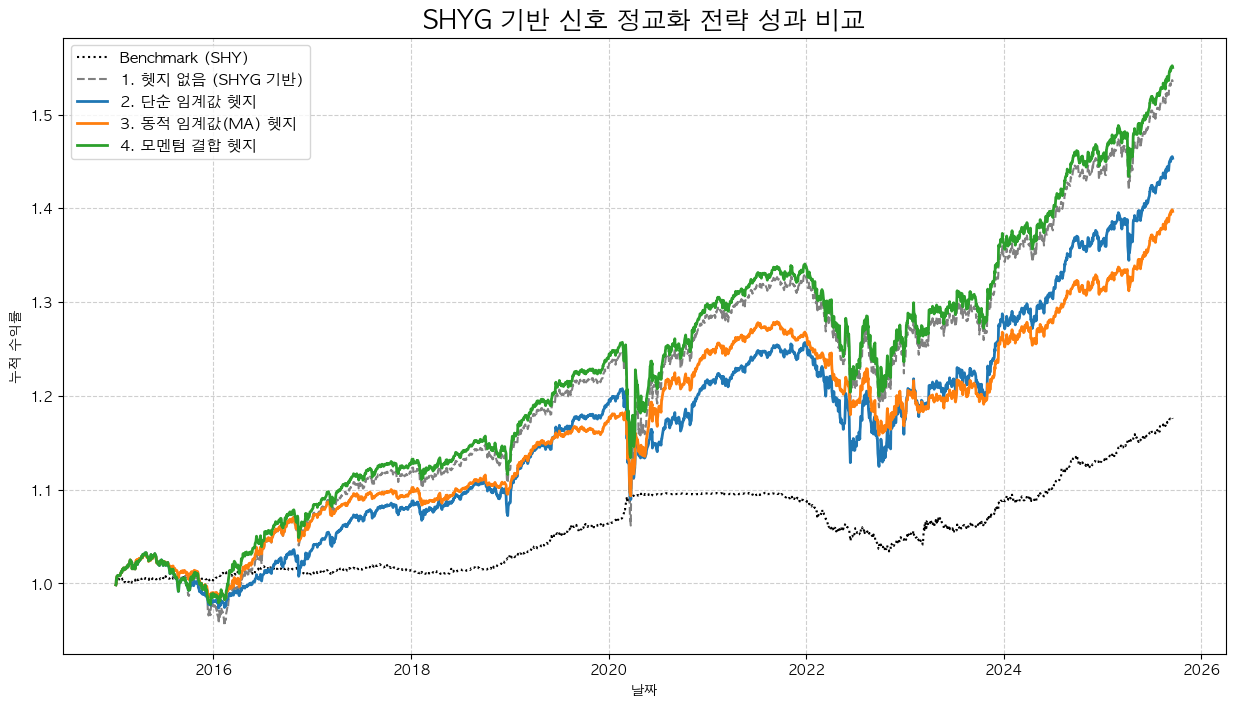

In [34]:
# --- 2.1 누적 수익률 그래프 비교 (SHYG) ---

# 비교 대상 포트폴리오 목록 (SHYG 기준)
comparison_list_shyg = ['SHY', 'Barbell_SHYG_Opt', 'Hedged_SHYG_Lagged', 'Hedged_A_Dynamic_SHYG', 'Hedged_B_Combined_SHYG']
cumulative_returns_shyg = (1 + returns_hedge[comparison_list_shyg].dropna()).cumprod()

# 시각화
plt.figure(figsize=(15, 8))
plt.plot(cumulative_returns_shyg['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
plt.plot(cumulative_returns_shyg['Barbell_SHYG_Opt'], label='1. 헷지 없음 (SHYG 기반)', linestyle='--', color='gray')
plt.plot(cumulative_returns_shyg['Hedged_SHYG_Lagged'], label='2. 단순 임계값 헷지', linewidth=2.0)
plt.plot(cumulative_returns_shyg['Hedged_A_Dynamic_SHYG'], label='3. 동적 임계값(MA) 헷지', linewidth=2.0)
plt.plot(cumulative_returns_shyg['Hedged_B_Combined_SHYG'], label='4. 모멘텀 결합 헷지', linewidth=2.0)

plt.title('SHYG 기반 신호 정교화 전략 성과 비교', fontsize=18)
plt.xlabel('날짜')
plt.ylabel('누적 수익률')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [36]:
# --- 2.2 성과 지표 테이블 비교 (SHYG) ---

portfolios_shyg_comparison = ['SHY', 'Barbell_SHYG_Opt', 'Hedged_SHYG_Lagged', 'Hedged_A_Dynamic_SHYG', 'Hedged_B_Combined_SHYG']
metrics_data_shyg = {port: calculate_performance_metrics(returns_hedge[port].dropna()) for port in portfolios_shyg_comparison}
metrics_df_shyg = pd.DataFrame(metrics_data_shyg).T.round(2)
metrics_df_shyg.index = ['벤치마크 (SHY)', '1. 헷지 없음 (SHYG)', '2. 단순 임계값 (SHYG)', '3. 동적 임계값(MA) (SHYG)', '4. 모멘텀 결합 (SHYG)']

print("\n--- SHYG 기반 최종 전략별 성과 지표 비교 ---")
metrics_df_shyg


--- SHYG 기반 최종 전략별 성과 지표 비교 ---


,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
벤치마크 (SHY),1.53,1.53,1.00,-5.71,0.27
1. 헷지 없음 (SHYG),4.09,5.43,0.75,-14.86,0.28
2. 단순 임계값 (SHYG),3.56,4.58,0.78,-10.52,0.34
3. 동적 임계값(MA) (SHYG),3.18,3.77,0.84,-9.47,0.34
4. 모멘텀 결합 (SHYG),4.19,4.96,0.85,-10.52,0.40


### 점진적 헷지전략

In [37]:
# --- 1. 점진적 헷지(Graduated Hedging) 백테스팅 ---

# --- 1.1 헷지 신호 생성 ---
# 각 위험 단계별 OAS 임계값 계산
oas_thresh_85 = df_hedge['OAS'].quantile(0.85)
oas_thresh_90 = df_hedge['OAS'].quantile(0.90)
oas_thresh_95 = df_hedge['OAS'].quantile(0.95)

print("--- 점진적 헷지 임계값 ---")
print(f"주의보 (10% 헷지): OAS > {oas_thresh_85:.2f}")
print(f"경보   (20% 헷지): OAS > {oas_thresh_90:.2f}")
print(f"위험   (30% 헷지): OAS > {oas_thresh_95:.2f}\n")

# 각 날짜에 적용될 헷지 비율을 계산하는 함수
def get_graduated_hedge_ratio(oas_value):
    if oas_value > oas_thresh_95:
        return 0.30  # 위험
    elif oas_value > oas_thresh_90:
        return 0.20  # 경보
    elif oas_value > oas_thresh_85:
        return 0.10  # 주의보
    else:
        return 0.0   # 평상시

# 모든 날짜에 대해 헷지 비율 계산 후, 시차(Lag) 적용
df_hedge['Graduated_Ratio'] = df_hedge['OAS'].apply(get_graduated_hedge_ratio).shift(1)


# --- 1.2 백테스팅 실행 ---
# SHYG 기반 포트폴리오의 기본 수익률
base_return_shyg = returns_hedge['SHYG'] * new_w_shyg + returns_hedge['IEF'] * new_w_ief_2

# 날짜에 맞게 헷지 비율 신호 정렬
graduated_signal_aligned = df_hedge['Graduated_Ratio'].reindex(returns_hedge.index).fillna(0.0)

# 동적 포트폴리오 수익률 계산
# 포트폴리오 수익률 = (기본 포트폴리오 수익률 * (1 - 헷지비율)) + (헷지자산 수익률 * 헷지비율)
dynamic_returns_graduated = base_return_shyg * (1 - graduated_signal_aligned) + returns_hedge['SJB'] * graduated_signal_aligned
returns_hedge['Hedged_Graduated_SHYG'] = dynamic_returns_graduated

print("점진적 헷지 전략 백테스팅을 완료했습니다.")

--- 점진적 헷지 임계값 ---
주의보 (10% 헷지): OAS > 5.30
경보   (20% 헷지): OAS > 5.97
위험   (30% 헷지): OAS > 6.71

점진적 헷지 전략 백테스팅을 완료했습니다.


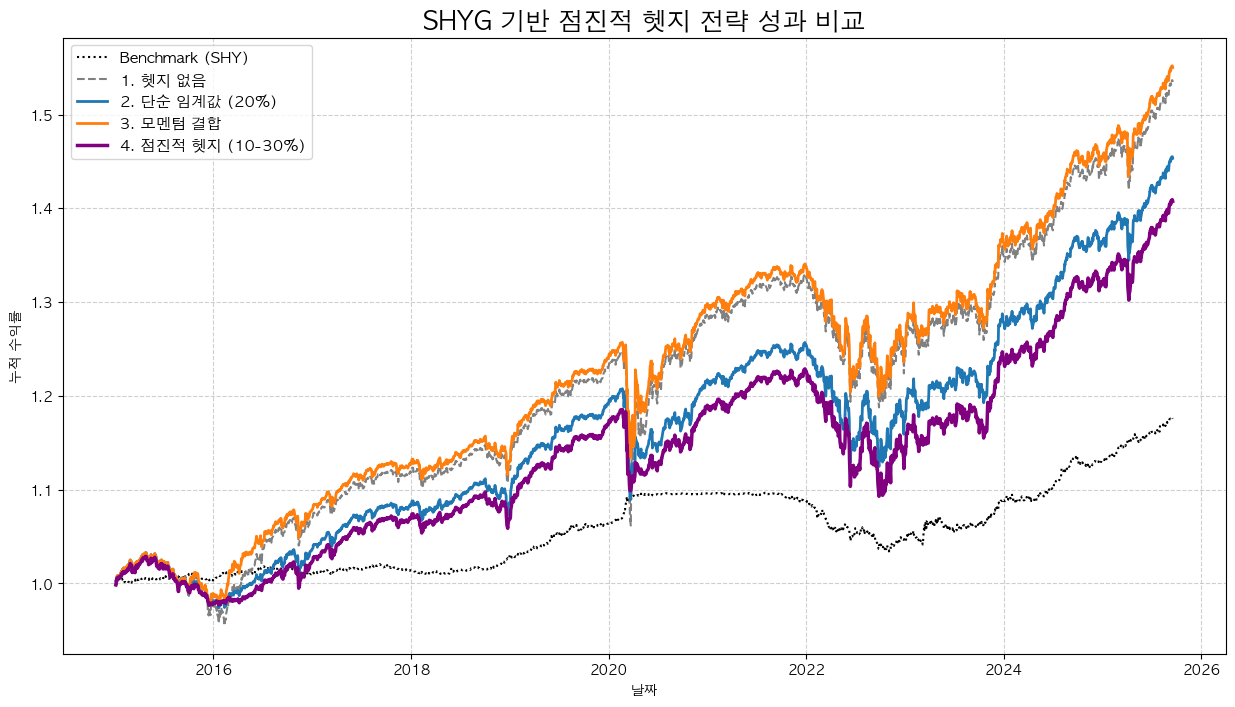

In [38]:
# --- 2.1 누적 수익률 그래프 비교 ---

# 비교 대상: 헷지 없음, 단순 임계값, 모멘텀 결합, 점진적 헷지
comparison_list_graduated = ['SHY', 'Barbell_SHYG_Opt', 'Hedged_SHYG_Lagged', 'Hedged_B_Combined_SHYG', 'Hedged_Graduated_SHYG']
cumulative_returns_graduated = (1 + returns_hedge[comparison_list_graduated].dropna()).cumprod()

# 시각화
plt.figure(figsize=(15, 8))
plt.plot(cumulative_returns_graduated['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
plt.plot(cumulative_returns_graduated['Barbell_SHYG_Opt'], label='1. 헷지 없음', linestyle='--', color='gray')
plt.plot(cumulative_returns_graduated['Hedged_SHYG_Lagged'], label='2. 단순 임계값 (20%)', linewidth=2.0)
plt.plot(cumulative_returns_graduated['Hedged_B_Combined_SHYG'], label='3. 모멘텀 결합', linewidth=2.0)
plt.plot(cumulative_returns_graduated['Hedged_Graduated_SHYG'], label='4. 점진적 헷지 (10-30%)', linewidth=2.5, color='purple')

plt.title('SHYG 기반 점진적 헷지 전략 성과 비교', fontsize=18)
plt.xlabel('날짜')
plt.ylabel('누적 수익률')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [39]:
# --- 2.2 성과 지표 테이블 비교 ---

portfolios_graduated_comparison = ['SHY', 'Barbell_SHYG_Opt', 'Hedged_SHYG_Lagged', 'Hedged_B_Combined_SHYG', 'Hedged_Graduated_SHYG']
metrics_data_graduated = {port: calculate_performance_metrics(returns_hedge[port].dropna()) for port in portfolios_graduated_comparison}
metrics_df_graduated = pd.DataFrame(metrics_data_graduated).T.round(2)
metrics_df_graduated.index = ['벤치마크 (SHY)', '1. 헷지 없음', '2. 단순 임계값', '3. 모멘텀 결합', '4. 점진적 헷지']

print("\n--- SHYG 기반 최종 전략별 성과 지표 비교 ---")
metrics_df_graduated


--- SHYG 기반 최종 전략별 성과 지표 비교 ---


,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
벤치마크 (SHY),1.53,1.53,1.00,-5.71,0.27
1. 헷지 없음,4.09,5.43,0.75,-14.86,0.28
2. 단순 임계값,3.56,4.58,0.78,-10.52,0.34
3. 모멘텀 결합,4.19,4.96,0.85,-10.52,0.40
4. 점진적 헷지,3.25,4.30,0.76,-11.06,0.29


### hybrid 전략

In [40]:
# --- 1. 하이브리드(Hybrid) 헷지 전략 백테스팅 ---

# --- 1.1 하이브리드 신호 생성 ---
# '모멘텀 결합' 신호가 True일 때만, '점진적 헷지' 비율을 적용하고, 아닐 경우 0으로 설정
df_hedge['Hybrid_Ratio'] = np.where(df_hedge['Signal_B_Combined'], df_hedge['Graduated_Ratio'], 0.0)


# --- 1.2 백테스팅 실행 ---
# SHYG 기반 포트폴리오의 기본 수익률
base_return_shyg = returns_hedge['SHYG'] * new_w_shyg + returns_hedge['IEF'] * new_w_ief_2

# 날짜에 맞게 하이브리드 헷지 비율 신호 정렬
hybrid_signal_aligned = df_hedge['Hybrid_Ratio'].reindex(returns_hedge.index).fillna(0.0)

# 동적 포트폴리오 수익률 계산
dynamic_returns_hybrid = base_return_shyg * (1 - hybrid_signal_aligned) + returns_hedge['SJB'] * hybrid_signal_aligned
returns_hedge['Hedged_Hybrid_SHYG'] = dynamic_returns_hybrid

print("하이브리드 헷지 전략 백테스팅을 완료했습니다.")

하이브리드 헷지 전략 백테스팅을 완료했습니다.


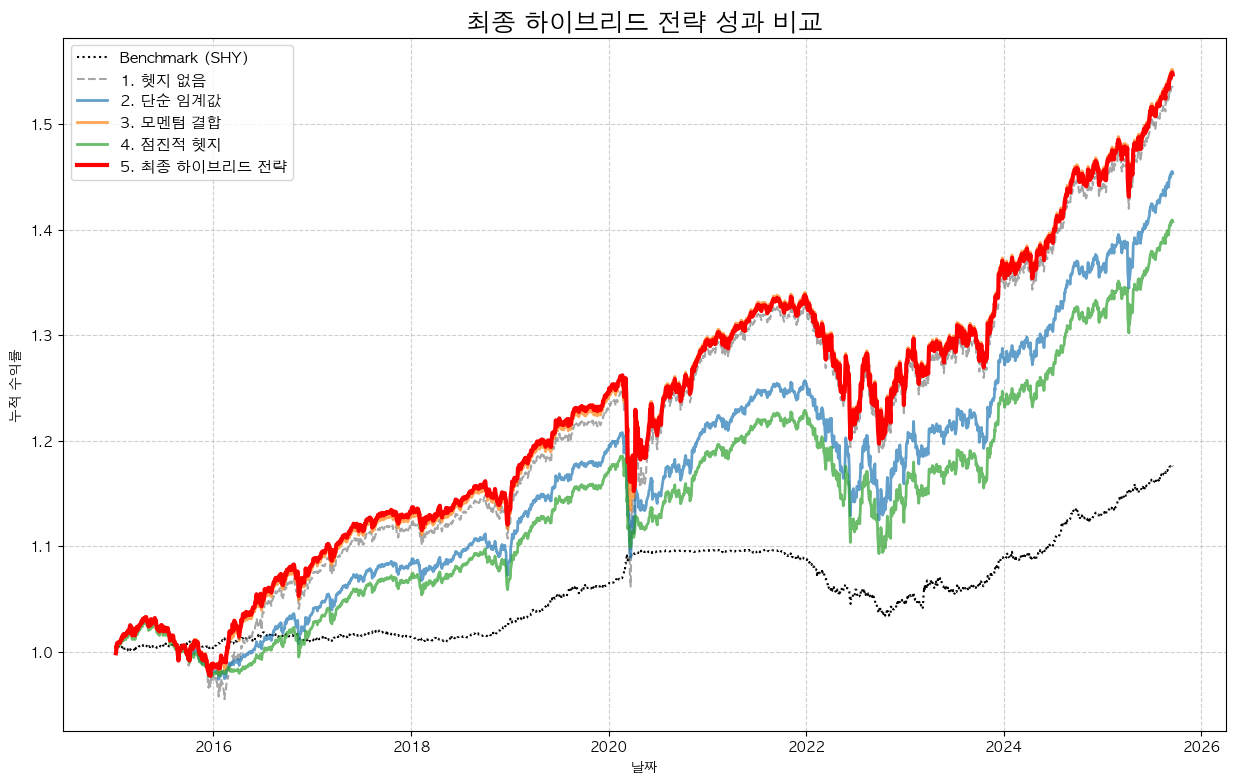

In [44]:
# --- 2.1 누적 수익률 최종 비교 ---

# 최종 비교 대상 목록
final_comparison_list = ['SHY', 'Barbell_SHYG_Opt', 'Hedged_SHYG_Lagged', 'Hedged_B_Combined_SHYG', 'Hedged_Graduated_SHYG', 'Hedged_Hybrid_SHYG']
cumulative_returns_ultimate = (1 + returns_hedge[final_comparison_list].dropna()).cumprod()

# 시각화
plt.figure(figsize=(15, 9))
plt.plot(cumulative_returns_ultimate['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
plt.plot(cumulative_returns_ultimate['Barbell_SHYG_Opt'], label='1. 헷지 없음', linestyle='--', color='gray', alpha=0.7)
plt.plot(cumulative_returns_ultimate['Hedged_SHYG_Lagged'], label='2. 단순 임계값', linewidth=2.0, alpha=0.7)
plt.plot(cumulative_returns_ultimate['Hedged_B_Combined_SHYG'], label='3. 모멘텀 결합', linewidth=2.0, alpha=0.7)
plt.plot(cumulative_returns_ultimate['Hedged_Graduated_SHYG'], label='4. 점진적 헷지', linewidth=2.0, alpha=0.7)
plt.plot(cumulative_returns_ultimate['Hedged_Hybrid_SHYG'], label='5. 최종 하이브리드 전략', linewidth=3.0, color='red')

plt.title('최종 하이브리드 전략 성과 비교', fontsize=18)
plt.xlabel('날짜')
plt.ylabel('누적 수익률')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [43]:
# --- 2.2 최종 성과 지표 비교 ---

final_portfolios_comparison = ['SHY', 'Barbell_SHYG_Opt', 'Hedged_SHYG_Lagged', 'Hedged_B_Combined_SHYG', 'Hedged_Graduated_SHYG', 'Hedged_Hybrid_SHYG']
final_metrics_data = {port: calculate_performance_metrics(returns_hedge[port].dropna()) for port in final_portfolios_comparison}
final_metrics_df = pd.DataFrame(final_metrics_data).T.round(2)
final_metrics_df.index = ['벤치마크', '1. 헷지 없음', '2. 단순 임계값', '3. 모멘텀 결합', '4. 점진적 헷지', '🏆 5. 최종 하이브리드']

print("\n--- 최종 전략별 성과 지표 비교 ---")
final_metrics_df


--- 최종 전략별 성과 지표 비교 ---


,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
벤치마크,1.53,1.53,1.00,-5.71,0.27
1. 헷지 없음,4.09,5.43,0.75,-14.86,0.28
2. 단순 임계값,3.56,4.58,0.78,-10.52,0.34
3. 모멘텀 결합,4.19,4.96,0.85,-10.52,0.40
4. 점진적 헷지,3.25,4.30,0.76,-11.06,0.29
🏆 5. 최종 하이브리드,4.17,4.88,0.85,-10.52,0.40


## 최종전략

### 최종 전략의 핵심 로직

이 전략은 두 개의 엔진으로 작동합니다.

1. **동적 자산 배분**
    - **목표**: 시장의 큰 추세를 파악하여 포트폴리오의 기본 공격/수비 태세를 조절합니다.
    - **신호**: S&P 500 지수와 200일 이동평균선을 비교하여 시장이 상승 추세인지 하락 추세인지 판단합니다.
    - **실행**:
        - **상승 추세 (Risk-On)**: 기존의 공격적인 바벨 비중(SHYG 89% + IEF 11%)을 유지합니다.
        - **하락 추세 (Risk-Off)**: 선제적으로 방어적인 비중(SHYG 60% + IEF 40%)으로 변경합니다.
2. **엔진 2: 다중 신호 헷지 (특수 위기 대응)**
    - **목표**: 여러 종류의 위기 신호를 종합적으로 판단하여 특수 방어막(SJB)을 펼칩니다.
    - **신호 (종합 위험 계기판)**:
        1. **신용 위험**: OAS Spread
        2. **금리/경기침체 위험**: 장단기 금리차 (10y-2y)
        3. **시장 공포**: VIX 지수
    - **실행**: 세 가지 지표 중 위험 임계값을 넘는 지표의 **개수(0~3개)**에 따라 헷지 비율을 **0%에서 30%까지 점진적으로** 조절합니다.

In [48]:
!pip install fredapi

In [49]:
# --- 1. 데이터 준비 (FRED API 키 사용) ---
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
from fredapi import Fred # fredapi 라이브러리 임포트

# --- [수정] FRED API 키 설정 ---
# ◀◀◀ 여기에 발급받은 FRED API 키를 입력하세요
api_key = 'f75d683dda2053416b64caae44e1bfb2'
fred = Fred(api_key=api_key)

# 필요한 모든 티커 정의
all_tickers = ['SHYG', 'IEF', 'SJB', 'SHY', '^VIX', 'SPY']
start_date = '2015-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%-m-%d')

# yfinance에서 시장 데이터 다운로드
market_data = yf.download(all_tickers, start=start_date, end=end_date)['Close']

# --- [수정] FRED API를 통해 거시 지표 다운로드 ---
fred_tickers = {'BAMLH0A0HYM2': 'OAS', 'T10Y2Y': 'Yield_Curve'}
macro_data = pd.DataFrame()

print("FRED API를 통해 데이터를 불러오는 중...")
for series_id, name in fred_tickers.items():
    series_data = fred.get_series(series_id, start_date=start_date, end_date=end_date)
    macro_data[name] = series_data
print("데이터 로딩 완료.")

# 모든 데이터를 하나의 데이터프레임으로 통합
df_final = market_data.join(macro_data, how='inner')
df_final.fillna(method='ffill', inplace=True) # 주말/휴일 데이터 채우기
df_final.dropna(inplace=True)

# 수익률 계산
returns_final = df_final[['SHYG', 'IEF', 'SJB']].pct_change().dropna()

print("\n모든 데이터 준비가 완료되었습니다. (최근 5일 데이터)")
print(df_final.tail())

/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_4767/4281179941.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(all_tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  6 of 6 completed


FRED API를 통해 데이터를 불러오는 중...
데이터 로딩 완료.

모든 데이터 준비가 완료되었습니다. (최근 5일 데이터)
                  IEF        SHY       SHYG    SJB         SPY       ^VIX  \
2025-09-12  96.980003  82.930000  43.220001  15.53  657.409973  14.760000   
2025-09-15  97.139999  82.959999  43.299999  15.51  660.909973  15.690000   
2025-09-16  97.199997  83.000000  43.279999  15.51  660.000000  16.360001   
2025-09-17  96.989998  82.959999  43.250000  15.54  659.179993  15.720000   
2025-09-18  96.669998  82.930000  43.330002  15.51  662.260010  15.700000   

             OAS  Yield_Curve  
2025-09-12  2.79         0.50  
2025-09-15  2.75         0.51  
2025-09-16  2.79         0.53  
2025-09-17  2.79         0.54  
2025-09-18  2.71         0.54  


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_4767/4281179941.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final.fillna(method='ffill', inplace=True) # 주말/휴일 데이터 채우기


### 2. 최종 전략 규칙 정의 및 신호 생성

In [50]:
# --- 2. 신호 생성 ---

# --- 엔진 1: 동적 자산배분 신호 ---
df_final['SPY_SMA200'] = df_final['SPY'].rolling(window=200).mean()
# Risk-On 조건: SPY가 200일 이평선 위에 있을 때
df_final['Signal_Risk_On'] = (df_final['SPY'] > df_final['SPY_SMA200']).shift(1)


# --- 엔진 2: 다중 신호 헷지 신호 ---
# 각 지표별 위험 임계값 설정
oas_threshold = df_final['OAS'].quantile(0.90)
vix_threshold = df_final['^VIX'].quantile(0.85) # VIX는 변동성이 크므로 85% 사용
yield_curve_threshold = 0.1 # 장단기 금리차가 0.1%p 미만일 때 위험

# 각 지표가 임계값을 넘었는지 여부 (True=1, False=0)
signal_oas = (df_final['OAS'] > oas_threshold)
signal_vix = (df_final['^VIX'] > vix_threshold)
signal_yc = (df_final['Yield_Curve'] < yield_curve_threshold)

# 종합 위험 점수 (0~3점) 계산
df_final['Risk_Score'] = (signal_oas.astype(int) + signal_vix.astype(int) + signal_yc.astype(int)).shift(1)

# 위험 점수에 따른 헷지 비율 매핑
hedge_ratio_mapping = {0: 0.0, 1: 0.10, 2: 0.20, 3: 0.30}
df_final['Ultimate_Hedge_Ratio'] = df_final['Risk_Score'].map(hedge_ratio_mapping)

print("모든 신호 생성 완료.")

모든 신호 생성 완료.


### 3. 최종 백테스팅 실행

In [51]:
# --- 3. 최종 백테스팅 실행 ---

# 동적 자산배분에 따른 두 가지 기본 포트폴리오 수익률 정의
# SHYG 비중: Risk-On(89%), Risk-Off(60%)
# IEF 비중: Risk-On(11%), Risk-Off(40%)
risk_on_return = returns_final['SHYG'] * 0.89 + returns_final['IEF'] * 0.11
risk_off_return = returns_final['SHYG'] * 0.60 + returns_final['IEF'] * 0.40

# 날짜에 맞게 신호 정렬
signal_risk_on_aligned = df_final['Signal_Risk_On'].reindex(returns_final.index).fillna(False)
ultimate_hedge_ratio_aligned = df_final['Ultimate_Hedge_Ratio'].reindex(returns_final.index).fillna(0.0)

# 엔진 1 적용: 동적 자산배분 포트폴리오의 일일 수익률 계산
core_portfolio_return = np.where(signal_risk_on_aligned, risk_on_return, risk_off_return)

# 엔진 2 적용: 헷지 오버레이
# 최종 수익률 = (코어 포트폴리오 수익률 * (1 - 헷지비율)) + (헷지자산 수익률 * 헷지비율)
ultimate_returns = core_portfolio_return * (1 - ultimate_hedge_ratio_aligned) + returns_final['SJB'] * ultimate_hedge_ratio_aligned
returns_final['Ultimate_Strategy'] = ultimate_returns

print("최종 전략 백테스팅 완료.")

최종 전략 백테스팅 완료.


/var/folders/ty/z_03r2t54ygddxrrfl1btc140000gp/T/ipykernel_4767/745389607.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  signal_risk_on_aligned = df_final['Signal_Risk_On'].reindex(returns_final.index).fillna(False)


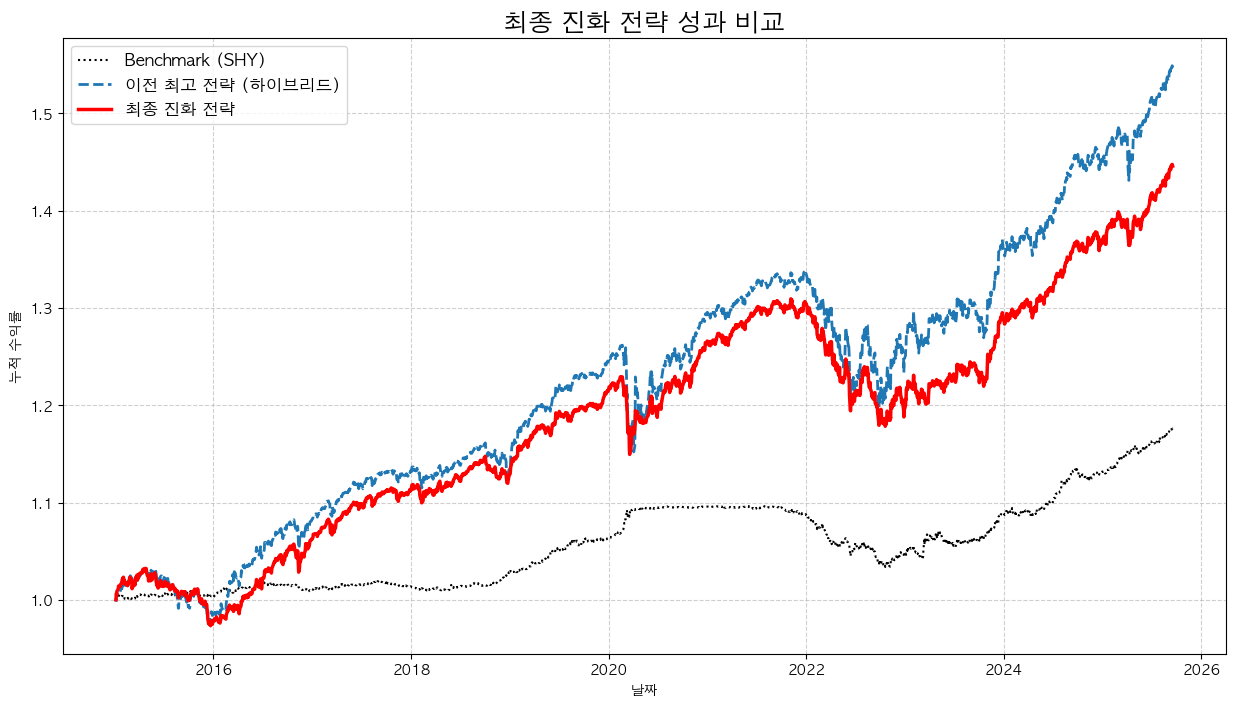


--- 최종 전략 성과 지표 ---


,CAGR (%),Volatility (%),Sharpe Ratio,MDD (%),Calmar Ratio
최종 하이브리드 전략,4.17,4.88,0.85,-10.52,0.40
⭐️최종 진화 전략,3.51,3.55,0.99,-10.00,0.35


In [60]:
# --- 4. 최종 성과 비교 ---
# 비교를 위해 이전 하이브리드 전략 수익률 복사
returns_final['Hedged_Hybrid_SHYG'] = returns_hedge['Hedged_Hybrid_SHYG']

comparison_list_ultimate = ['Hedged_Hybrid_SHYG', 'Ultimate_Strategy']
cumulative_returns_ultimate_final = (1 + returns_final[comparison_list_ultimate].dropna()).cumprod()

# 시각화
plt.figure(figsize=(15, 8))
plt.plot(cumulative_returns_ultimate['SHY'], label='Benchmark (SHY)', linestyle=':', color='black')
plt.plot(cumulative_returns_ultimate_final['Hedged_Hybrid_SHYG'], label='이전 최고 전략 (하이브리드)', linestyle='--', linewidth=2.0)
plt.plot(cumulative_returns_ultimate_final['Ultimate_Strategy'], label='최종 진화 전략', linewidth=2.5, color='red')
plt.title('최종 진화 전략 성과 비교', fontsize=18)
plt.xlabel('날짜')
plt.ylabel('누적 수익률')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 성과 지표
final_metrics_ultimate = {port: calculate_performance_metrics(returns_final[port].dropna()) for port in comparison_list_ultimate}
final_metrics_df_ultimate = pd.DataFrame(final_metrics_ultimate).T.round(2)
final_metrics_df_ultimate.index = ['최종 하이브리드 전략', '⭐️최종 진화 전략']

print("\n--- 최종 전략 성과 지표 ---")
final_metrics_df_ultimate